# validator 프로토타입 — 자연어 요구사항 모순 찾기

자연어 SW 요구사항 → LLM 형식화(formalization) → SMT 감사(audit) → 모순 리포트. 예제: **전기차 배터리 충전 제어기**.

이 노트북은 **클라이언트**다. 서버(`VALIDATOR_URL`)의 formalizer(LLM 형식화)와 checker(z3 검사)를 HTTP 로 부른다 — Colab 에 z3 도 API 키도 필요 없다.

**I. 구성** — 1 전체 구조 · 2 클라이언트 상세 · 3 클라이언트 코드 · 4 서버 API 문서 · 5 서버 상세와 코드(server.py · formalizer/ · checker.py)
**II. 예제** — 6 자연어 요구사항 · 7 실행(형식화 → 확인 → 검사) · 8 판정 JSON · 9 요구사항 고쳐 재검사 · 10 형식화 두 판 비교
**부록** — A anthropic provider 로 실제 형식화 · B `.smt2` 재현 · C 서버를 Colab 안에서 띄우기

저장소: `validator` (client/ + server/) · 배포: Render 서비스 `validator` — 주소는 3절 `VALIDATOR_URL`

<hr style="border:0;border-top:5px solid #B23A31;margin:36px 0 8px;">

# I. 구성

## 1. 전체 구조 — validator = client + server{formalizer, checker}

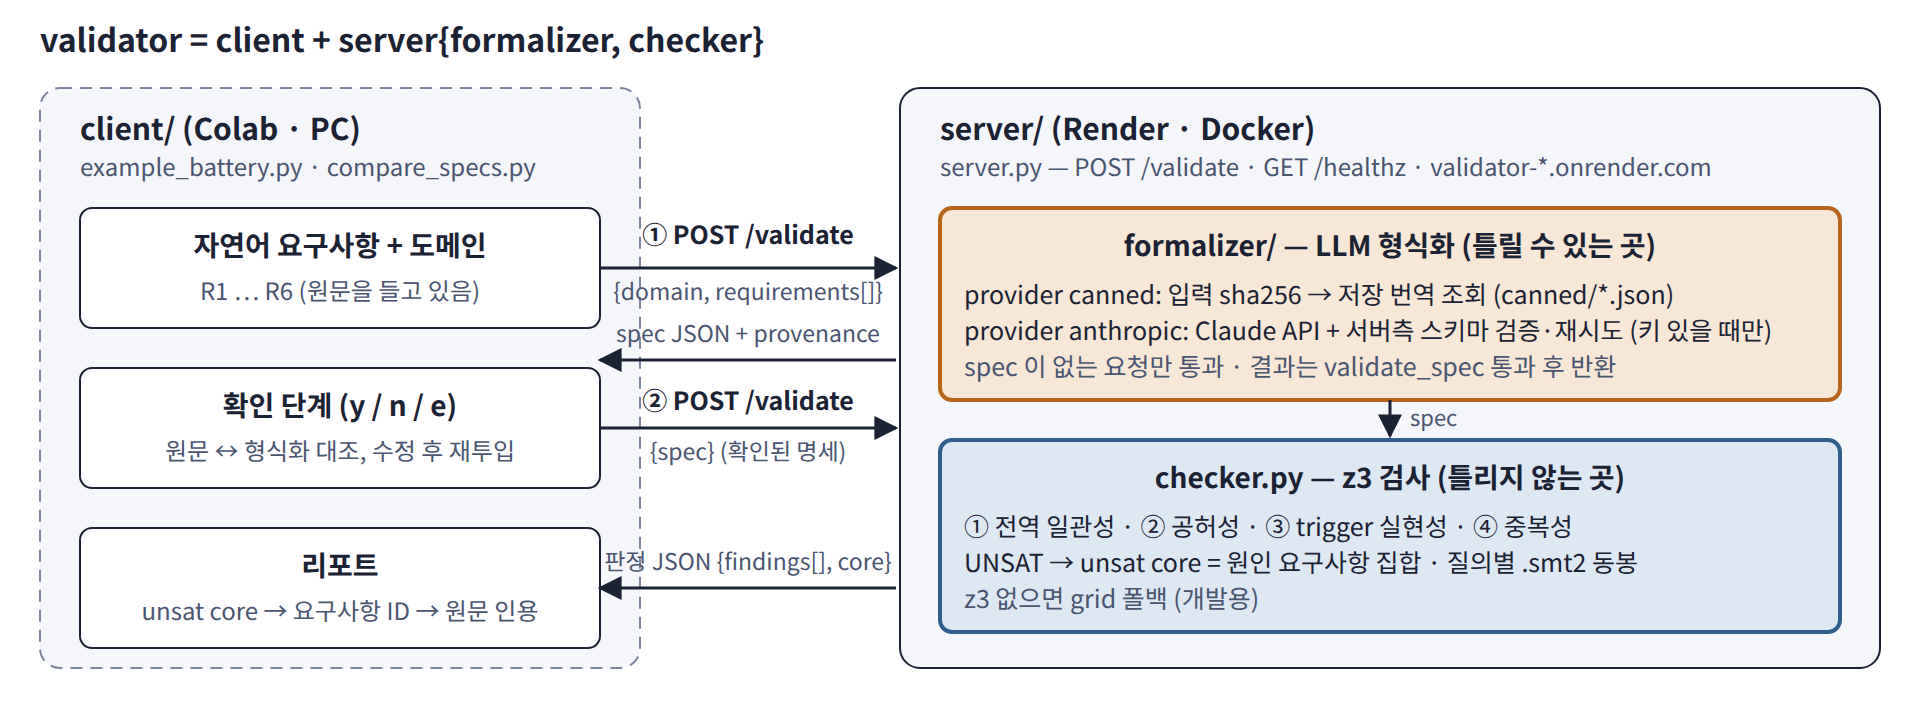

형식화(LLM, 틀릴 수 있는 곳)는 서버의 `formalizer/`에, 판정(z3, 틀리지 않는 곳)은 서버의 `checker.py`에. 클라이언트는 원문을 들고 있다가 형식화 결과를 사람이 확인하는 자리(y/n/e)를 갖고, 판정의 unsat core(요구사항 ID)를 원문으로 되돌려 리포트를 만든다.

## 2. 클라이언트 상세

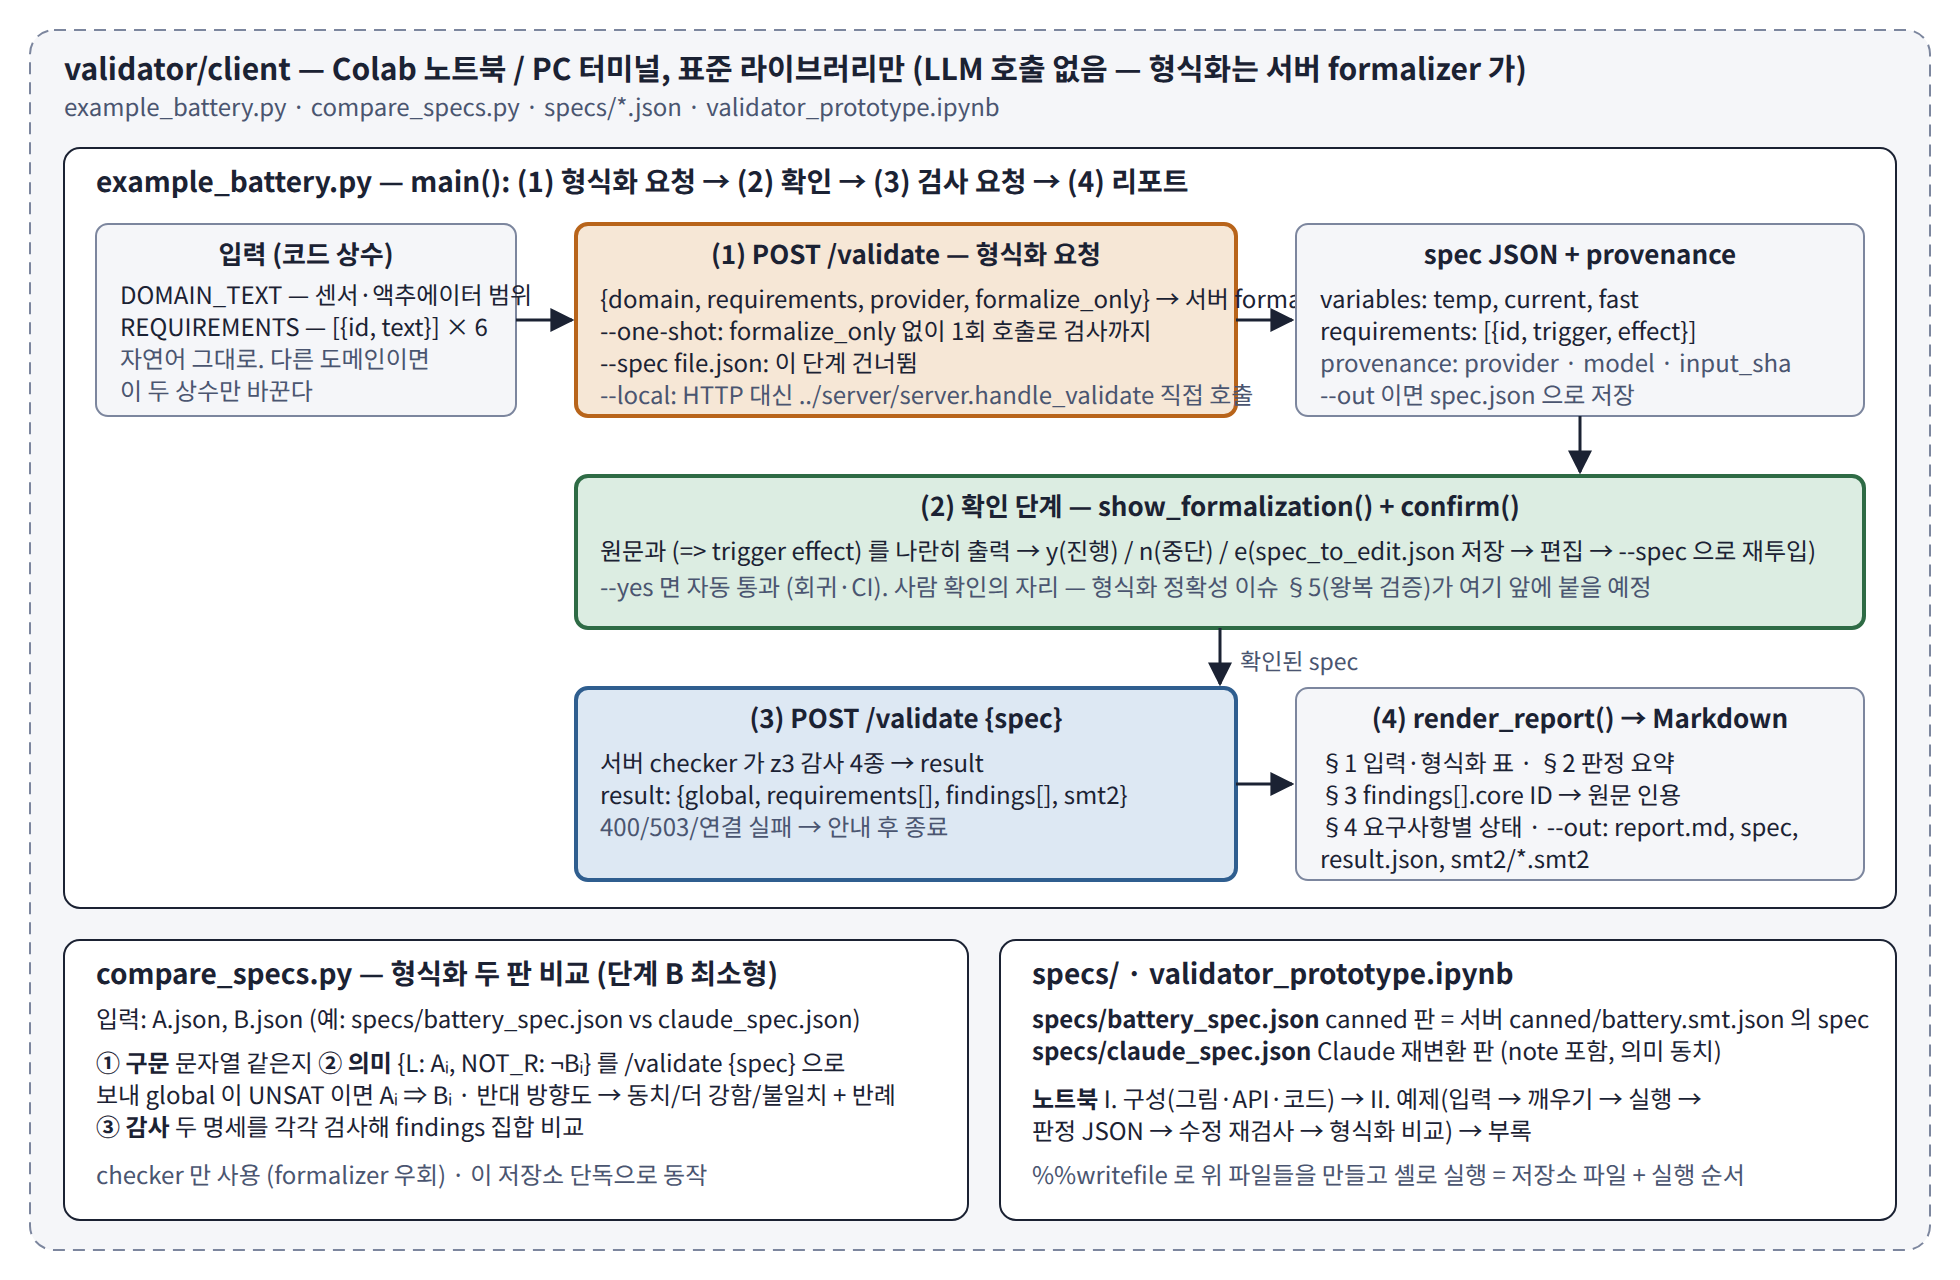

`example_battery.py` 의 (1) 형식화 요청 → (2) 확인 → (3) 검사 요청 → (4) 원문 인용 리포트. `compare_specs.py` 는 형식화 두 판을 checker 만으로 비교한다.

## 3. 클라이언트 코드

`example_battery.py` — 자연어 요구사항 6개를 들고 `/validate` 를 두 번 부른다(형식화 → 확인 → 검사). LLM 호출은 없다(서버 몫). 표준 라이브러리만 쓴다.

In [ ]:
!mkdir -p client specs server/formalizer/prompts server/formalizer/canned server/examples

In [ ]:
%%writefile client/example_battery.py
"""
client/example_battery.py — 예제 클라이언트: 전기차 배터리 충전 제어기 요구사항의 모순 찾기.

흐름:  자연어 요구사항 ──POST /validate (formalize_only)──▶ 명세 JSON ──(확인)──▶ POST /validate {spec} ──▶ 판정 JSON ──▶ 리포트

    python example_battery.py                                   # provider canned, 확인 프롬프트 y/n/e
    python example_battery.py --yes --out out/                  # 확인 자동 통과 (회귀·CI 용)
    python example_battery.py --provider anthropic              # 서버에 ANTHROPIC_API_KEY 가 있을 때
    python example_battery.py --one-shot                        # 1회 호출로 형식화+검사 (확인 단계 없음)
    python example_battery.py --spec specs/battery_spec.json    # 형식화 건너뛰고 검사만
    python example_battery.py --local                           # 서버 없이 ../server 의 formalizer·checker 직접 호출
    python example_battery.py --validator https://validator-c6wn.onrender.com

형식화(LLM, 틀릴 수 있는 곳)는 서버의 formalizer 가, 판정(z3, 틀리지 않는 곳)은 서버의 checker 가 한다.
클라이언트는 원문을 들고 있다가 결과의 요구사항 ID 를 원문으로 되돌려 리포트를 만든다.  표준 라이브러리만 사용.
"""
from __future__ import annotations

import argparse
import json
import os
import sys
import urllib.error
import urllib.request
from typing import Any, Dict, List

DEFAULT_URL = os.environ.get("VALIDATOR_URL", "https://validator-c6wn.onrender.com")

# ---------------------------------------------------------------------------
# 1. 자연어 요구사항 (입력)
# ---------------------------------------------------------------------------
DOMAIN_TEXT = (
    "배터리 온도 센서 측정 범위는 −20 °C ~ 80 °C, 충전 전류 지령 범위는 0 A ~ 50 A 이다. "
    "충전 모드는 급속(fast) 또는 일반이다."
)

REQUIREMENTS: List[Dict[str, str]] = [
    {"id": "R1", "text": "배터리 온도가 45 °C를 초과하면 충전 전류를 10 A 이하로 제한해야 한다."},
    {"id": "R2", "text": "급속 충전 모드에서는 충전 전류를 30 A 이상으로 유지해야 한다."},
    {"id": "R3", "text": "배터리 온도가 50 °C 이상이면 잔여 충전 시간을 줄이기 위해 급속 충전 모드로 전환해야 한다."},
    {"id": "R4", "text": "충전 전류는 어떤 경우에도 32 A를 넘어서는 안 된다."},
    {"id": "R5", "text": "배터리 온도가 60 °C 이상이면 충전 전류를 20 A 이하로 제한해야 한다."},
    {"id": "R6", "text": "배터리 온도가 −30 °C 미만이면 배터리 예열을 위해 급속 충전 모드로 전환해야 한다."},
]


# ---------------------------------------------------------------------------
# 2. 서버 호출
# ---------------------------------------------------------------------------
def post_validate(url: str, body: Dict[str, Any]) -> Dict[str, Any]:
    req = urllib.request.Request(url.rstrip("/") + "/validate", data=json.dumps(body).encode("utf-8"), method="POST",
                                 headers={"content-type": "application/json"})
    try:
        with urllib.request.urlopen(req, timeout=300) as resp:
            return json.load(resp)
    except urllib.error.HTTPError as e:
        detail = e.read().decode("utf-8", "replace")
        sys.exit(f"validator 오류 HTTP {e.code}: {detail}")
    except urllib.error.URLError as e:
        sys.exit(f"validator({url})에 연결할 수 없음: {e.reason}\n  → 먼저  python ../server/server.py  로 서버를 띄우거나 --local 을 쓰세요.")


def local_validate(body: Dict[str, Any]) -> Dict[str, Any]:
    sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath(__file__)), "..", "server"))
    import server as srv  # type: ignore
    code, obj = srv.handle_validate(body, keep_smt2=True)
    if code != 200:
        sys.exit(f"validator 오류 {code}: {json.dumps(obj, ensure_ascii=False)}")
    return obj


# ---------------------------------------------------------------------------
# 3. 확인 단계 — 형식화 결과를 원문과 나란히 보여 주고 y/n/e
# ---------------------------------------------------------------------------
def show_formalization(reqs, spec, provenance):
    text_of = {r["id"]: r["text"] for r in reqs}
    print(f"\n[형식화] provider={provenance.get('provider')} model={provenance.get('model', '-')}")
    print("변수:", ", ".join(f"{k}:{v['sort']}{v.get('range', '')}" for k, v in spec["variables"].items()))
    for r in spec["requirements"]:
        print(f"  {r['id']}  {text_of.get(r['id'], '')}\n        ⇒ (=> {r['trigger']} {r['effect']})")


def confirm(spec, out_dir) -> Dict[str, Any]:
    while True:
        ans = input("\n이 형식화로 검사할까요?  y(진행) / n(중단) / e(spec 저장 후 편집해서 --spec 으로 재투입): ").strip().lower()
        if ans == "y":
            return spec
        if ans == "n":
            sys.exit("중단")
        if ans == "e":
            os.makedirs(out_dir or ".", exist_ok=True)
            p = os.path.join(out_dir or ".", "spec_to_edit.json")
            json.dump(spec, open(p, "w", encoding="utf-8"), ensure_ascii=False, indent=2)
            sys.exit(f"{p} 에 저장. 편집 후:  python example_battery.py --spec {p}")


# ---------------------------------------------------------------------------
# 4. 리포트 — core 의 요구사항 ID 를 원문으로 되돌려 인용
# ---------------------------------------------------------------------------
def _fmt_witness(w, spec):
    parts = []
    for k, v in w.items():
        unit = spec["variables"].get(k, {}).get("unit", "")
        parts.append(f"{k}={v}{unit}" if not isinstance(v, bool) else f"{k}={'참' if v else '거짓'}")
    return ", ".join(parts)


def render_report(reqs, spec, result) -> str:
    text_of = {r["id"]: r["text"] for r in reqs}
    form_of = {r["id"]: r for r in spec["requirements"]}
    L = ["# 요구사항 모순 감사 리포트 — 전기차 배터리 충전 제어기", "",
         f"checker 백엔드: `{result['backend']}` · 요구사항 {result['n_requirements']}개 · {result['elapsed_ms']} ms", "",
         "## 1. 입력과 형식화", "", f"도메인: {DOMAIN_TEXT}", "",
         "| ID | 자연어 | trigger | effect |", "|---|---|---|---|"]
    for r in reqs:
        f = form_of[r["id"]]
        L.append(f"| {r['id']} | {r['text']} | `{f['trigger']}` | `{f['effect']}` |")
    L += ["", "## 2. 판정 요약", ""]
    g = result["global"]
    if g["status"] == "sat":
        L.append(f"- **전역 일관성: 만족 가능(SAT).** 예: {_fmt_witness(g['witness'], spec)}. "
                 "→ 모든 요구사항을 동시에 만족하는 상태가 존재하므로 전역 검사만으로는 문제가 보이지 않는다.")
    else:
        L.append(f"- **전역 모순(UNSAT).** 원인 집합: {', '.join(g['core'])}")
    kinds = {"conditional_conflict": "조건부 모순", "vacuous": "공허한 요구사항", "redundant": "중복 요구사항", "global_conflict": "전역 모순"}
    counts: Dict[str, int] = {}
    for f in result["findings"]:
        counts[f["kind"]] = counts.get(f["kind"], 0) + 1
    L += ["- 발견: " + (", ".join(f"{kinds[k]} {n}건" for k, n in counts.items()) or "없음"), "", "## 3. 발견 사항 (원문 인용)", ""]
    for n, f in enumerate(result["findings"], 1):
        if f["kind"] == "conditional_conflict":
            L += [f"### {n}. 조건부 모순 — {f['req']} 의 상황 `{f['trigger']}` 에서", "",
                  "이 상황이 실제로 벌어지면 다음 요구사항들을 동시에 지킬 방법이 없다 (unsat core):", ""]
            L += [f"- **{rid}** — {text_of[rid]}  (`{form_of[rid]['trigger']}` → `{form_of[rid]['effect']}`)" for rid in f["core"]]
        elif f["kind"] == "vacuous":
            L += [f"### {n}. 공허한 요구사항 — {f['req']}", "", f"- **{f['req']}** — {text_of[f['req']]}",
                  f"- trigger `{form_of[f['req']]['trigger']}` 는 도메인 범위 안에서 절대 참이 될 수 없다 → 한 번도 발동하지 않는다. 오타(단위·부호)이거나 도메인 기술이 틀렸을 가능성."]
        elif f["kind"] == "redundant":
            L += [f"### {n}. 중복 요구사항 — {f['req']}", "", f"- **{f['req']}** — {text_of[f['req']]}", "- 다음 요구사항(과 도메인)이 이미 함의한다:"]
            L += [f"  - **{rid}** — {text_of[rid]}" for rid in f["implied_by"]]
            L.append("- 삭제해도 명세의 의미는 같다. 다만 사람이 읽기 위한 강조라면 남겨도 된다.")
        elif f["kind"] == "global_conflict":
            L += [f"### {n}. 전역 모순", ""] + [f"- **{rid}** — {text_of[rid]}" for rid in f["core"] if rid in text_of]
        L.append("")
    L += ["## 4. 요구사항별 상태", "", "| ID | trigger 상태 | 실현 예 (witness) | 중복 |", "|---|---|---|---|"]
    status_ko = {"realizable": "실현 가능", "conflict": "충돌", "vacuous": "공허", "unconditional": "무조건"}
    for r in result["requirements"]:
        w = _fmt_witness(r["witness"], spec) if r.get("witness") else "—"
        red = f"예 (← {', '.join(r['implied_by'])})" if r.get("redundant") else "아니오"
        L.append(f"| {r['id']} | {status_ko.get(r.get('trigger_status', ''), '')} | {w} | {red} |")
    if result.get("smt2"):
        L += ["", f"질의별 SMT-LIB2 파일 {len(result['smt2'])}개는 --out 디렉터리의 smt2/ 에 저장된다 (`z3 파일.smt2` 로 재현)."]
    return "\n".join(L) + "\n"


# ---------------------------------------------------------------------------
def main():
    ap = argparse.ArgumentParser(description=__doc__, formatter_class=argparse.RawDescriptionHelpFormatter)
    ap.add_argument("--validator", default=DEFAULT_URL, help="validator 서버 주소 (환경변수 VALIDATOR_URL)")
    ap.add_argument("--provider", choices=["canned", "anthropic"], default="canned")
    ap.add_argument("--model", help="--provider anthropic 일 때 모델명")
    ap.add_argument("--spec", help="이미 형식화된 명세 JSON — 형식화 건너뛰고 검사만")
    ap.add_argument("--one-shot", action="store_true", help="형식화+검사를 한 번의 호출로 (확인 단계 없음)")
    ap.add_argument("--yes", action="store_true", help="확인 프롬프트 자동 통과")
    ap.add_argument("--local", action="store_true", help="HTTP 대신 ../server 를 직접 import")
    ap.add_argument("--out", help="리포트·명세·판정·smt2 저장 디렉터리")
    a = ap.parse_args()
    call = local_validate if a.local else (lambda body: post_validate(a.validator, body))

    if a.spec:                                              # 검사만
        spec = json.load(open(a.spec, encoding="utf-8"))
        res = call({"spec": spec})
        provenance = {"provider": "file", "model": a.spec}
    else:
        nl = {"logic": "smt", "domain": DOMAIN_TEXT, "requirements": REQUIREMENTS, "provider": a.provider}
        if a.model:
            nl["model"] = a.model
        if a.one_shot:                                      # 1회 호출
            res = call(nl)
            spec, provenance = res["spec"], res["provenance"]
        else:                                               # 2회 호출: 형식화 → 확인 → 검사
            first = call({**nl, "formalize_only": True})
            spec, provenance = first["spec"], first["provenance"]
            show_formalization(REQUIREMENTS, spec, provenance)
            if not a.yes:
                spec = confirm(spec, a.out)
            res = call({"spec": spec})
    result = res["result"]

    report = render_report(REQUIREMENTS, spec, result)
    print(report)
    if a.out:
        os.makedirs(os.path.join(a.out, "smt2"), exist_ok=True)
        open(os.path.join(a.out, "report.md"), "w", encoding="utf-8").write(report)
        json.dump(spec, open(os.path.join(a.out, "spec.json"), "w", encoding="utf-8"), ensure_ascii=False, indent=2)
        json.dump({k: v for k, v in result.items() if k != "smt2"} | {"provenance": provenance},
                  open(os.path.join(a.out, "result.json"), "w", encoding="utf-8"), ensure_ascii=False, indent=2)
        for name, txt in result.get("smt2", {}).items():
            open(os.path.join(a.out, "smt2", f"{name}.smt2"), "w", encoding="utf-8").write(txt)
        print(f"[saved] {a.out}/report.md, spec.json, result.json, smt2/*.smt2 ({len(result.get('smt2', {}))}개)", file=sys.stderr)


if __name__ == "__main__":
    main()


`compare_specs.py` — 형식화 두 판을 구문·의미(SMT 동치)·감사결과로 비교. checker 만 사용(spec 모드).

In [ ]:
%%writefile client/compare_specs.py
"""
compare_specs.py — 두 형식화 결과(명세 JSON)를 validator API(checker)만으로 비교한다.  단계 B(형식화 신뢰성)의 최소 형태.

    python compare_specs.py specs/battery_spec.json specs/claude_spec.json
    python compare_specs.py A.json B.json --validator https://validator-c6wn.onrender.com

① 요구사항별 문자열 비교(구문)
② 요구사항별 SMT 동치(의미): 서버의 전역 일관성 검사를 이용 —
     명세 {L: Aᵢ, NOT_R: ¬Bᵢ} 의 global 이 unsat 이면 DOM ∧ Aᵢ ∧ ¬Bᵢ 가 불가능, 즉 Aᵢ ⇒ Bᵢ.
     반대 방향도 같이 보아 둘 다 성립하면 동치.  sat 이면 global.witness 가 반례.  (DOM 은 A 의 variables 기준)
③ 두 명세 각각 감사해 findings 비교
표준 라이브러리만 사용.
"""
import argparse, json, os, sys, urllib.request


def audit(url, spec):
    """spec 모드로 POST /validate → result (판정 JSON)"""
    req = urllib.request.Request(url.rstrip("/") + "/validate?smt2=0", data=json.dumps({"spec": spec}).encode(),
                                 headers={"content-type": "application/json"}, method="POST")
    with urllib.request.urlopen(req, timeout=180) as r:
        return json.load(r)["result"]


def formula(r):
    return r["effect"] if r["trigger"].strip() == "true" else f"(=> {r['trigger']} {r['effect']})"


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("a"); ap.add_argument("b")
    ap.add_argument("--validator", default=os.environ.get("VALIDATOR_URL", "https://validator-c6wn.onrender.com"))
    a = ap.parse_args()
    A, B = (json.load(open(p, encoding="utf-8")) for p in (a.a, a.b))
    ra = {r["id"]: r for r in A["requirements"]}
    print(f"validator: {a.validator}\n")
    print(f"{'ID':4} {'구문':6} {'A⇒B':5} {'B⇒A':5} 판정")
    print("-" * 60)
    for rb in B["requirements"]:
        r_a = ra.get(rb["id"])
        if r_a is None:
            print(f"{rb['id']:4} A 에 없음"); continue
        same = (r_a["trigger"].strip(), r_a["effect"].strip()) == (rb["trigger"].strip(), rb["effect"].strip())
        def implies(lhs, rhs):
            """DOM ∧ lhs ∧ ¬rhs 가 UNSAT 이면 lhs ⇒ rhs.  (unsat, witness)"""
            spec = {"logic": "smt", "variables": A["variables"],
                    "requirements": [{"id": "L", "trigger": "true", "effect": lhs},
                                     {"id": "NOT_R", "trigger": "true", "effect": f"(not {rhs})"}]}
            g = audit(a.validator, spec)["global"]
            return g["status"] == "unsat", g.get("witness")
        ab, wit_ab = implies(formula(r_a), formula(rb))   # A ⇒ B
        ba, wit_ba = implies(formula(rb), formula(r_a))   # B ⇒ A
        verdict = "동치" if ab and ba else ("A 가 더 강함" if ab else ("B 가 더 강함" if ba else "불일치"))
        print(f"{rb['id']:4} {'같음' if same else '다름':6} {'✓' if ab else '✗':5} {'✓' if ba else '✗':5} {verdict}")
        if not same:
            print(f"       A: {formula(r_a)}\n       B: {formula(rb)}")
        if not ab and wit_ab:
            print(f"       반례 A∧¬B: {wit_ab}")
        if not ba and wit_ba:
            print(f"       반례 B∧¬A: {wit_ba}")

    print("\n③ 감사 결과 비교")
    fa, fb = audit(a.validator, A)["findings"], audit(a.validator, B)["findings"]
    key = lambda f: (f["kind"], f.get("req"), tuple(f.get("implied_by") or f.get("core") or []))
    sa, sb = {key(f) for f in fa}, {key(f) for f in fb}
    for k in sorted(sa | sb):
        print(f"  {'양쪽' if k in sa and k in sb else ('A만' if k in sa else 'B만'):4} {k[0]:20s} {k[1]}  {list(k[2])}")


if __name__ == "__main__":
    main()


`specs/` — 미리 변환해 둔(canned) 형식화 결과와 Claude 가 다시 변환한 결과.

In [ ]:
%%writefile specs/battery_spec.json
{
  "logic": "smt",
  "variables": {
    "temp":    {"sort": "Real", "range": [-20, 80], "unit": "°C"},
    "current": {"sort": "Real", "range": [0, 50],  "unit": "A"},
    "fast":    {"sort": "Bool"}
  },
  "requirements": [
    {"id": "R1", "trigger": "(> temp 45)",    "effect": "(<= current 10)"},
    {"id": "R2", "trigger": "fast",           "effect": "(>= current 30)"},
    {"id": "R3", "trigger": "(>= temp 50)",   "effect": "fast"},
    {"id": "R4", "trigger": "true",           "effect": "(<= current 32)"},
    {"id": "R5", "trigger": "(>= temp 60)",   "effect": "(<= current 20)"},
    {"id": "R6", "trigger": "(< temp (- 30))","effect": "fast"}
  ]
}


In [ ]:
%%writefile specs/claude_spec.json
{
  "logic": "smt",
  "variables": {
    "temp":    {"sort": "Real", "range": [-20, 80], "unit": "°C", "meaning": "배터리 온도 (센서 측정값)"},
    "current": {"sort": "Real", "range": [0, 50],  "unit": "A",  "meaning": "충전 전류 지령"},
    "fast":    {"sort": "Bool",                                  "meaning": "급속 충전 모드 활성 (거짓 = 일반 모드)"}
  },
  "requirements": [
    {"id": "R1", "trigger": "(> temp 45)",              "effect": "(<= current 10)",
     "note": "'초과' → 엄격 부등호 >. '이하로 제한' → <=."},
    {"id": "R2", "trigger": "(= fast true)",            "effect": "(>= current 30)",
     "note": "'급속 충전 모드에서는' = 모드가 활성인 동안. '30 A 이상 유지' → >=. 일반 모드에 대한 언급은 없으므로 역방향 제약 없음."},
    {"id": "R3", "trigger": "(>= temp 50)",             "effect": "(= fast true)",
     "note": "'이상' → >=. '급속 모드로 전환해야 한다'는 동작(전이)이지만 한 시점 상태 논리에서는 '그 조건에서 급속 모드여야 한다'로 읽음. '잔여 충전 시간을 줄이기 위해'는 근거이므로 제약에 넣지 않음."},
    {"id": "R4", "trigger": "true",                     "effect": "(not (> current 32))",
     "note": "'어떤 경우에도' → 무조건. '넘어서는 안 된다' → ¬(current > 32), 즉 current <= 32 와 동치."},
    {"id": "R5", "trigger": "(>= temp 60)",             "effect": "(<= current 20)",
     "note": "'이상' → >=."},
    {"id": "R6", "trigger": "(< temp (- 30))",          "effect": "(= fast true)",
     "note": "'미만' → <. −30 은 도메인(−20~80) 밖이라 trigger 가 거짓일 수밖에 없음을 변환 시점에 인지했으나, 원문에 충실하게 그대로 옮김 — 판정은 검증기의 몫."}
  ]
}


## 4. 서버 API 문서 — validator

**역할.** 자연어 요구사항(또는 이미 형식화된 명세)을 받아 모순·공허·중복을 판정해 돌려주는 HTTP 서버. `server.py` 가 두 모듈을 잇는다 — **formalizer**(자연어 → 명세, LLM, 틀릴 수 있는 곳)와 **checker**(명세 → 판정, z3, 틀리지 않는 곳). 어떤 언어로든 `POST` 한 번이면 쓸 수 있다.

- 기본 URL: `https://validator-c6wn.onrender.com` (Render 서비스명 `validator`)
- 인증 없음. 무료 인스턴스라 15분 미사용 시 절전, 첫 호출 ~1분 → `/healthz` 로 먼저 깨운다.
- `ANTHROPIC_API_KEY` 가 서버에 있으면 provider `anthropic` 이 켜지고, 없으면 저장 번역(`canned`)만.

---

### `GET /healthz` — 상태 확인·깨우기

```json
{"ok": true, "checker": {"backend": "z3 5.1.0", "z3": true}, "formalizer": {"providers": ["canned"], "canned": ["battery.smt"]}}
```
`checker.z3` 가 `false` 면 grid 폴백(개발용) — 배포판은 항상 `true` 여야 한다.

---

### `POST /validate` — 두 가지 입력 모드 (`?smt2=0` 이면 `result.smt2` 생략 · `POST /audit` 는 별칭)

**(a) 자연어 모드** — formalizer → checker

```json
{"logic": "smt",
 "domain": "배터리 온도 센서 측정 범위는 −20 °C ~ 80 °C, 충전 전류 지령 범위는 0 A ~ 50 A 이다. 충전 모드는 급속(fast) 또는 일반이다.",
 "requirements": [{"id": "R1", "text": "배터리 온도가 45 °C를 초과하면 충전 전류를 10 A 이하로 제한해야 한다."}, {"id": "R2", "text": "..."}],
 "provider": "canned",
 "formalize_only": false}
```

| 필드 | 뜻 |
|---|---|
| `provider` | `canned`(기본): 도메인+원문을 정규화한 sha256 으로 저장 번역 조회. 원문이 한 글자라도 다르면 `400 no canned translation` + `input_sha`. `anthropic`: Claude API 호출, 서버가 스키마 검증·3회 재시도. 키 없으면 `503` |
| `formalize_only` | `true` 면 검사 없이 `{"status": "awaiting_confirmation", "spec", "provenance"}` 를 돌려준다 — 사람이 형식화를 확인한 뒤 (b) 로 다시 보내는 2단계 흐름 |
| 응답 | `{"status": "checked", "spec", "provenance": {provider, model, input_sha, …}, "result"}` |

**(b) 명세 모드** — checker 만

```json
{"spec": {
  "logic": "smt",
  "variables": {"temp": {"sort": "Real", "range": [-20, 80], "unit": "°C"}, "current": {"sort": "Real", "range": [0, 50], "unit": "A"}, "fast": {"sort": "Bool"}},
  "requirements": [{"id": "R1", "trigger": "(> temp 45)", "effect": "(<= current 10)"}, {"id": "R4", "trigger": "true", "effect": "(<= current 32)"}]
}}
```

| 필드 | 규칙 |
|---|---|
| `variables.<name>.sort` / `range` | `Bool` · `Int` · `Real`; 수치형은 `[lo, hi]` 필수 — 도메인 제약 `DOM` 이 된다 |
| `requirements[].trigger` / `effect` | SMT-LIB Bool 식. 요구사항은 `(=> trigger effect)`. 무조건이면 trigger `"true"` |
| 허용 연산자 | `and or not => xor ite = distinct < <= > >= + - * /` · 음수 리터럴 `(- 30)` |
| 응답 | `{"status": "checked", "result"}` |

**`result` (판정 JSON)**

```json
{"backend": "z3 5.1.0", "n_requirements": 6, "elapsed_ms": 41.2,
 "global": {"status": "sat", "witness": {"temp": -20, "current": 0, "fast": false}, "core": []},
 "requirements": [{"id": "R3", "trigger_status": "conflict", "core": ["R1", "R2", "R3", "TRIG_R3"], "redundant": false}, "..."],
 "findings": [
   {"kind": "conditional_conflict", "req": "R3", "trigger": "(>= temp 50)", "core": ["R1", "R2", "R3"], "message": "..."},
   {"kind": "vacuous", "req": "R6", "core": ["DOM", "TRIG_R6"], "message": "..."},
   {"kind": "redundant", "req": "R5", "implied_by": ["R1"], "core": ["DOM", "NOT_R5", "R1"], "message": "..."}],
 "smt2": {"global": "(set-option :produce-unsat-cores true) ...", "trigger_R3": "..."}}
```

| `findings[].kind` | 뜻 | 핵심 필드 |
|---|---|---|
| `global_conflict` | 모든 요구사항을 동시에 만족하는 상태가 없음 | `core` |
| `conditional_conflict` | `req` 의 trigger 상황에서 `core` 의 요구사항들을 동시에 지킬 수 없음 | `req`, `trigger`, `core` |
| `vacuous` | `req` 의 trigger 가 도메인 안에서 절대 참이 안 됨 | `req` |
| `redundant` | `req` 는 `implied_by`(와 도메인)가 이미 함의 | `req`, `implied_by` |

`requirements[].trigger_status` ∈ `realizable` · `conflict` · `vacuous` · `unconditional`. `core` 의 원소는 요구사항 ID 또는 `DOM`, `TRIG_<id>`, `NOT_<id>` — 클라이언트는 요구사항 ID 만 골라 원문으로 되돌린다. 감사 4종: ① 전역 일관성 sat(DOM ∧ ⋀R) ② 공허성 sat(DOM ∧ trigᵢ) ③ trigger 실현성 sat(DOM ∧ ⋀R ∧ trigᵢ) ④ 중복성 sat(DOM ∧ ⋀R∖Rᵢ ∧ ¬Rᵢ) — UNSAT 이면 unsat core 가 원인 집합.

**오류** — `400` JSON·스키마·canned 미존재(`{"error", "detail" | "input_sha", "hint"}`) · `503` provider 없음 · `500` 내부.

---

### 호출 예

```bash
URL=https://validator-c6wn.onrender.com
curl -s $URL/healthz
curl -s -X POST "$URL/validate?smt2=0" -H "content-type: application/json" --data @battery_input.json      # 자연어 모드
curl -s -X POST "$URL/validate?smt2=0" -H "content-type: application/json" --data "{\"spec\": $(cat battery_spec.json)}"
```

통합 테스트: `python server/tests/test_api.py $URL` — spec 모드·자연어 모드·2단계·canned 미존재 400·잘못된 spec 400·`/audit` 별칭.


## 5. 서버 상세와 코드

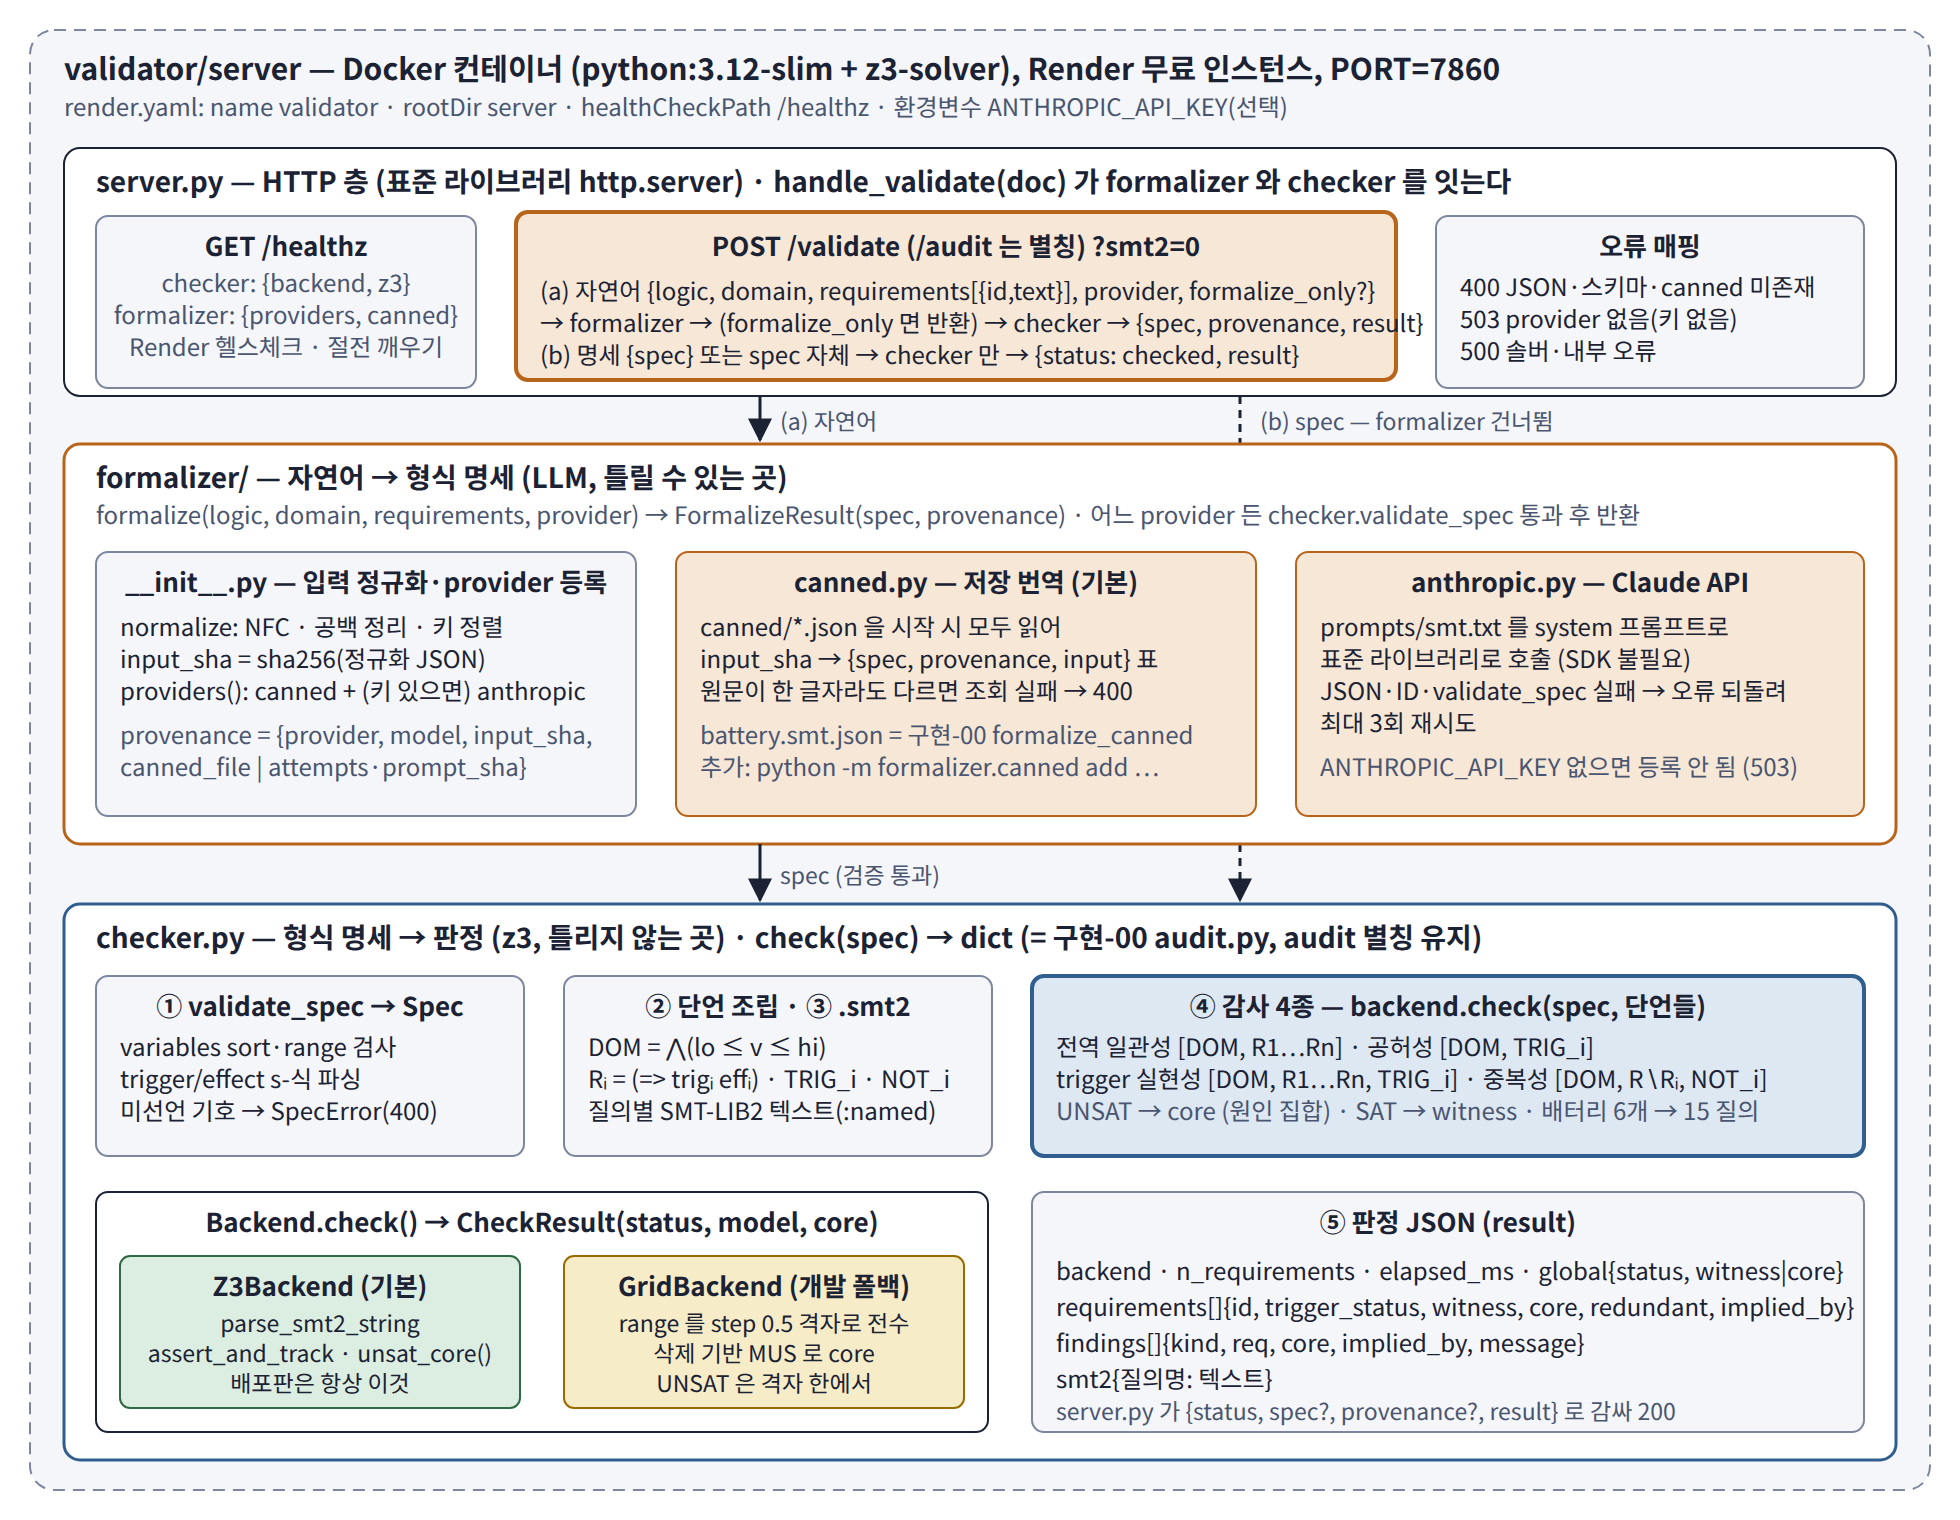

`server.py`(HTTP 층)의 `handle_validate` 가 요청 형태를 보고 갈린다 — 자연어면 `formalizer.formalize()` 로 명세를 만든 뒤(또는 `formalize_only` 면 거기서 반환) `checker.check()`, 명세면 `checker.check()` 만. `formalizer/` 는 provider 둘(canned: 입력 해시로 저장 번역 조회 / anthropic: Claude API + 서버측 검증·재시도)을 같은 시그니처로 제공하고, `checker.py` 는 명세 검증 → 단언 조립 → 감사 4종 → 판정 JSON 을 z3(없으면 grid 폴백)로 돈다.

아래 셀들은 **Render 에 올라간 것과 같은 코드**를 참고용으로 기록한다. 실행해도 파일만 만들어질 뿐 서버가 뜨지는 않는다 — Colab 안에서 띄우려면 부록 C.

In [ ]:
%%writefile server/server.py
"""
server/server.py — validator 의 HTTP API.  formalizer(LLM 형식화) + checker(z3 검사) 두 모듈을 묶는다.

    python server.py                # http://0.0.0.0:8000   (PORT 환경변수 우선)
    python server.py --port 9000

엔드포인트
    GET  /healthz     → {"ok", "checker": {"backend", "z3"}, "formalizer": {"providers", "canned"}}
    POST /validate    ← 두 가지 입력 형태
        (a) 자연어:  {"logic": "smt", "domain": "...", "requirements": [{"id","text"}], "provider": "canned"|"anthropic",
                      "model"?: "...", "formalize_only"?: false}
            → formalizer 로 spec 을 만들고, formalize_only 가 아니면 이어서 checker 로 검사
            → {"status": "checked", "spec", "provenance", "result"}   또는   {"status": "awaiting_confirmation", "spec", "provenance"}
        (b) 명세:    {"spec": {...}}  또는 spec 자체 ({"variables", "requirements"} 가 최상위)
            → checker 만  → {"status": "checked", "result"}
        ?smt2=0  이면 result.smt2 생략
    POST /audit       → /validate 와 같은 핸들러 (구현-00 호환 별칭)
    GET  /            → 이 도움말

오류: 400 {"error", "detail"} (입력·스키마·canned 미존재) · 503 (provider 없음) · 500 (내부)
표준 라이브러리만 사용.  LLM 키는 서버 환경변수 ANTHROPIC_API_KEY (없으면 canned provider 만).
"""
from __future__ import annotations

import argparse
import json
import os
import sys
import traceback
from http.server import BaseHTTPRequestHandler, ThreadingHTTPServer
from urllib.parse import parse_qs, urlparse

sys.path.insert(0, os.path.dirname(os.path.abspath(__file__)))
import checker  # noqa: E402
import formalizer  # noqa: E402
from formalizer import canned as canned_provider  # noqa: E402

HELP = __doc__


def handle_validate(doc, keep_smt2: bool):
    """요청 본문 → (status_code, 응답 dict).  HTTP 를 모르는 순수 함수라 테스트에서 직접 부를 수 있다."""
    if not isinstance(doc, dict):
        return 400, {"error": "spec error", "detail": "최상위는 JSON 객체여야 함"}
    # (b) 명세 모드
    spec = doc.get("spec") if "spec" in doc else (doc if "requirements" in doc and "variables" in doc else None)
    if spec is not None:
        try:
            result = checker.check(spec, keep_smt2=keep_smt2)
        except checker.SpecError as e:
            return 400, {"error": "spec error", "detail": str(e)}
        return 200, {"status": "checked", "result": result}
    # (a) 자연어 모드
    try:
        fr = formalizer.formalize(doc.get("logic", "smt"), doc.get("domain", ""), doc.get("requirements"),
                                  provider=doc.get("provider", "canned"), model=doc.get("model"))
    except formalizer.FormalizeError as e:
        return e.status, {"error": str(e), **e.extra}
    except checker.SpecError as e:
        return 400, {"error": "spec error", "detail": str(e)}
    if doc.get("formalize_only"):
        return 200, {"status": "awaiting_confirmation", "spec": fr.spec, "provenance": fr.provenance}
    result = checker.check(fr.spec, keep_smt2=keep_smt2)
    return 200, {"status": "checked", "spec": fr.spec, "provenance": fr.provenance, "result": result}


class Handler(BaseHTTPRequestHandler):
    server_version = "validator/0.2"

    def _send(self, code: int, obj, ctype="application/json"):
        body = (json.dumps(obj, ensure_ascii=False, indent=1) if ctype.startswith("application/json") else obj).encode("utf-8")
        self.send_response(code)
        self.send_header("Content-Type", ctype + "; charset=utf-8")
        self.send_header("Content-Length", str(len(body)))
        self.send_header("Access-Control-Allow-Origin", "*")
        self.end_headers()
        self.wfile.write(body)

    def do_GET(self):
        path = urlparse(self.path).path
        if path == "/healthz":
            be = checker.default_backend()
            return self._send(200, {"ok": True,
                                    "checker": {"backend": be.name, "z3": checker.HAVE_Z3},
                                    "formalizer": {"providers": formalizer.providers(), "canned": canned_provider.available()},
                                    # 구현-00 호환 필드
                                    "backend": be.name, "z3": checker.HAVE_Z3})
        if path == "/":
            return self._send(200, HELP, ctype="text/plain")
        return self._send(404, {"error": f"no such path: {path}"})

    def do_POST(self):
        u = urlparse(self.path)
        if u.path not in ("/validate", "/audit"):
            return self._send(404, {"error": f"no such path: {u.path}"})
        try:
            n = int(self.headers.get("Content-Length", "0"))
            doc = json.loads(self.rfile.read(n).decode("utf-8"))
        except Exception as e:
            return self._send(400, {"error": f"invalid JSON body: {e}"})
        keep = parse_qs(u.query).get("smt2", ["1"])[0] not in ("0", "false")
        try:
            code, obj = handle_validate(doc, keep)
        except Exception as e:  # 솔버·내부 오류
            traceback.print_exc()
            return self._send(500, {"error": "internal error", "detail": repr(e)})
        return self._send(code, obj)

    def log_message(self, fmt, *args):
        sys.stderr.write("%s - %s\n" % (self.address_string(), fmt % args))


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--host", default="0.0.0.0")
    ap.add_argument("--port", type=int, default=int(os.environ.get("PORT", "8000")))
    a = ap.parse_args()
    srv = ThreadingHTTPServer((a.host, a.port), Handler)
    print(f"validator listening on http://{a.host}:{a.port}  checker={checker.default_backend().name}  "
          f"formalizer providers={formalizer.providers()} canned={canned_provider.available()}", flush=True)
    try:
        srv.serve_forever()
    except KeyboardInterrupt:
        pass


if __name__ == "__main__":
    main()


In [ ]:
%%writefile server/formalizer/__init__.py
"""
server/formalizer — 자연어 요구사항 → 형식 명세(JSON) 변환 모듈.  "틀릴 수 있는 곳".

    formalize(logic, domain, requirements, provider="canned", model=None) -> FormalizeResult(spec, provenance)

provider
    canned     입력(도메인 문장 + 요구사항 원문)을 정규화해 sha256 을 만들고 canned/*.json 에서 저장된 번역을 찾는다.
               원문이 한 글자라도 바뀌면 조회가 실패(FormalizeError)하므로 저장된 번역이 다른 원문에 붙는 일이 없다.
    anthropic  Claude API 호출.  ANTHROPIC_API_KEY 가 있을 때만 등록된다.  응답을 checker.validate_spec 으로 검증해
               실패하면 오류를 되돌려 주며 최대 3회 재시도한다.

두 provider 는 같은 시그니처를 구현하고, 결과는 항상 checker.validate_spec 을 통과한 뒤에 반환된다.
"""
from __future__ import annotations

import hashlib
import json
import os
import unicodedata
from dataclasses import dataclass, field
from typing import Any, Dict, List, Optional


class FormalizeError(ValueError):
    """형식화 실패 — HTTP 400 (canned 미존재·스키마 위반) 또는 503 (provider 없음) 으로 매핑."""

    def __init__(self, msg: str, status: int = 400, **extra):
        super().__init__(msg)
        self.status = status
        self.extra = extra


@dataclass
class FormalizeResult:
    spec: Dict[str, Any]
    provenance: Dict[str, Any] = field(default_factory=dict)


def normalize_input(logic: str, domain: str, requirements: List[Dict[str, str]]) -> str:
    """입력 정규화 — NFC, 공백 정리, 키 정렬.  이 문자열의 sha256 이 canned 조회 키."""
    def clean(s: str) -> str:
        return " ".join(unicodedata.normalize("NFC", s).split())
    return json.dumps({"logic": logic, "domain": clean(domain),
                       "requirements": [[r["id"], clean(r["text"])] for r in requirements]},
                      sort_keys=True, ensure_ascii=False)


def input_sha(logic: str, domain: str, requirements: List[Dict[str, str]]) -> str:
    return hashlib.sha256(normalize_input(logic, domain, requirements).encode("utf-8")).hexdigest()


def providers() -> List[str]:
    ps = ["canned"]
    if os.environ.get("ANTHROPIC_API_KEY"):
        ps.append("anthropic")
    return ps


def formalize(logic: str, domain: str, requirements: List[Dict[str, str]], *,
              provider: str = "canned", model: Optional[str] = None) -> FormalizeResult:
    if not isinstance(requirements, list) or not requirements or \
       not all(isinstance(r, dict) and isinstance(r.get("id"), str) and isinstance(r.get("text"), str) for r in requirements):
        raise FormalizeError("requirements 는 [{id, text}] 배열이어야 함")
    if provider == "canned":
        from . import canned
        res = canned.formalize(logic, domain, requirements)
    elif provider == "anthropic":
        if "anthropic" not in providers():
            raise FormalizeError("provider unavailable: ANTHROPIC_API_KEY 가 서버에 없음", status=503)
        from . import anthropic
        res = anthropic.formalize(logic, domain, requirements, model=model)
    else:
        raise FormalizeError(f"unknown provider {provider!r} (available: {providers()})")
    # 어느 provider 든 스키마 검증을 통과한 것만 내보낸다
    import checker
    checker.validate_spec(res.spec)
    res.provenance.setdefault("provider", provider)
    res.provenance["input_sha"] = input_sha(logic, domain, requirements)
    return res


In [ ]:
%%writefile server/formalizer/canned.py
"""
formalizer/canned.py — 저장된 번역(canned) provider.

canned/*.json 형식:
    {"input_sha": "<sha256>", "logic": "smt", "provenance": {...}, "spec": {...}, "notes": {...}}
서버 시작 시 디렉터리를 모두 읽어 input_sha → 파일 표를 만든다.  파일 이름은 사람용이고 조회 키가 아니다.
같은 입력을 다시 저장하려면 tools 없이 `python -m formalizer.canned add <name> <input.json> <spec.json>` 으로 만든다.
"""
from __future__ import annotations

import glob
import json
import os
from typing import Any, Dict, List

from . import FormalizeError, FormalizeResult, input_sha

CANNED_DIR = os.path.join(os.path.dirname(os.path.abspath(__file__)), "canned")
_TABLE: Dict[str, Dict[str, Any]] = {}


def _load() -> Dict[str, Dict[str, Any]]:
    if not _TABLE:
        for p in sorted(glob.glob(os.path.join(CANNED_DIR, "*.json"))):
            d = json.load(open(p, encoding="utf-8"))
            d["_file"] = os.path.basename(p)
            _TABLE[d["input_sha"]] = d
    return _TABLE


def available() -> List[str]:
    return [d["_file"].rsplit(".json", 1)[0] for d in _load().values()]


def formalize(logic: str, domain: str, requirements: List[Dict[str, str]]) -> FormalizeResult:
    sha = input_sha(logic, domain, requirements)
    d = _load().get(sha)
    if d is None:
        raise FormalizeError("no canned translation for this input", input_sha=sha, available=available(),
                             hint="원문이 저장본과 한 글자라도 다르면 조회에 실패한다. provider=anthropic 을 쓰거나 canned 파일을 추가할 것")
    prov = dict(d.get("provenance", {}))
    prov["canned_file"] = d["_file"]
    return FormalizeResult(spec=d["spec"], provenance=prov)


if __name__ == "__main__":  # python -m formalizer.canned add <name> <input.json> <spec.json>
    import sys
    if len(sys.argv) == 5 and sys.argv[1] == "add":
        name, inp, spec = sys.argv[2:]
        i = json.load(open(inp, encoding="utf-8"))
        out = {"input_sha": input_sha(i["logic"], i["domain"], i["requirements"]), "logic": i["logic"],
               "provenance": {"provider": "canned", "model": "manual"}, "spec": json.load(open(spec, encoding="utf-8"))}
        path = os.path.join(CANNED_DIR, name + ".json")
        json.dump(out, open(path, "w", encoding="utf-8"), ensure_ascii=False, indent=2)
        print("wrote", path, out["input_sha"])
    else:
        print(__doc__)


In [ ]:
%%writefile server/formalizer/anthropic.py
"""
formalizer/anthropic.py — Claude API provider.  표준 라이브러리로 호출 (SDK 불필요).
구현-00 client/example_battery.py 의 formalize_anthropic 을 서버로 옮긴 것.  검증은 checker.validate_spec 으로 서버에서 한다.
"""
from __future__ import annotations

import hashlib
import json
import os
import urllib.request
from typing import Dict, List, Optional

from . import FormalizeError, FormalizeResult

PROMPT_PATH = os.path.join(os.path.dirname(os.path.abspath(__file__)), "prompts", "smt.txt")
DEFAULT_MODEL = "claude-sonnet-4-5"


def _system_prompt() -> str:
    return open(PROMPT_PATH, encoding="utf-8").read()


def formalize(logic: str, domain: str, requirements: List[Dict[str, str]], *, model: Optional[str] = None,
              retries: int = 3) -> FormalizeResult:
    import checker  # 서버 sys.path 에 server/ 가 있음
    if logic != "smt":
        raise FormalizeError(f"logic {logic!r} 는 아직 지원하지 않음 (smt 만)")
    key = os.environ["ANTHROPIC_API_KEY"]
    model = model or DEFAULT_MODEL
    system = _system_prompt()
    user = "Domain:\n" + domain + "\n\nRequirements:\n" + "\n".join(f"{r['id']}. {r['text']}" for r in requirements)
    messages = [{"role": "user", "content": user}]
    last_err = ""
    for attempt in range(1, retries + 1):
        body = json.dumps({"model": model, "max_tokens": 2048, "system": system, "messages": messages}).encode()
        req = urllib.request.Request("https://api.anthropic.com/v1/messages", data=body, method="POST",
                                     headers={"content-type": "application/json", "x-api-key": key,
                                              "anthropic-version": "2023-06-01"})
        with urllib.request.urlopen(req, timeout=120) as resp:
            out = json.load(resp)
        text = "".join(b.get("text", "") for b in out.get("content", [])).strip()
        if text.startswith("```"):
            text = text.strip("`").split("\n", 1)[1] if "\n" in text else text
            text = text.rsplit("```", 1)[0]
        try:
            spec = json.loads(text)
            ids_in = [r["id"] for r in requirements]
            ids_out = [r.get("id") for r in spec.get("requirements", [])]
            if ids_in != ids_out:
                raise ValueError(f"requirement ids mismatch: expected {ids_in}, got {ids_out}")
            checker.validate_spec(spec)          # 스키마·문법 검증 — 실패 메시지를 그대로 되돌려 준다
            return FormalizeResult(spec=spec, provenance={
                "provider": "anthropic", "model": model, "attempts": attempt,
                "prompt_sha": hashlib.sha256(system.encode()).hexdigest()[:16]})
        except Exception as e:
            last_err = str(e)
            messages += [{"role": "assistant", "content": text},
                         {"role": "user", "content": f"Your output was rejected: {last_err}. Return ONLY the corrected JSON."}]
    raise FormalizeError(f"형식화 {retries}회 실패: {last_err}")


In [ ]:
%%writefile server/formalizer/prompts/smt.txt
You translate natural-language software requirements into a JSON specification
for an SMT-based consistency checker. Output ONLY a JSON object, no prose, no markdown fences.

Schema:
{
  "logic": "smt",
  "variables": { "<name>": {"sort": "Bool"|"Int"|"Real", "range": [lo, hi], "unit": "...", "meaning": "..."} , ... },
  "requirements": [ {"id": "<id from input>", "trigger": "<SMT-LIB Bool expr>", "effect": "<SMT-LIB Bool expr>"}, ... ]
}
Rules:
- Every numeric variable MUST have a finite "range" taken from the domain description (sensor/actuator limits).
- Each requirement is read as (=> trigger effect). Use trigger "true" for unconditional requirements.
- Allowed SMT-LIB operators: and or not => xor ite = distinct < <= > >= + - * /. Negative literal: (- 30).
- Use the SAME variable for the same physical quantity across all requirements (e.g. one "temp", one "current").
- Booleans for modes (e.g. "fast" = fast-charging mode is active).
- Keep the ids exactly as given. Do not invent requirements. Rationale phrases ("in order to ...") are not constraints.


In [ ]:
%%writefile server/formalizer/canned/battery.smt.json
{
  "input_sha": "59dea8b7df8b5950061ed0232fb8f0cc3c7b324be2f123239225f8dc92ec9749",
  "logic": "smt",
  "provenance": {
    "provider": "canned",
    "model": "claude (2026-09-11 세션에서 수동 번역; 구현-00 formalize_canned)"
  },
  "input": {
    "domain": "배터리 온도 센서 측정 범위는 −20 °C ~ 80 °C, 충전 전류 지령 범위는 0 A ~ 50 A 이다. 충전 모드는 급속(fast) 또는 일반이다.",
    "requirements": [
      {
        "id": "R1",
        "text": "배터리 온도가 45 °C를 초과하면 충전 전류를 10 A 이하로 제한해야 한다."
      },
      {
        "id": "R2",
        "text": "급속 충전 모드에서는 충전 전류를 30 A 이상으로 유지해야 한다."
      },
      {
        "id": "R3",
        "text": "배터리 온도가 50 °C 이상이면 잔여 충전 시간을 줄이기 위해 급속 충전 모드로 전환해야 한다."
      },
      {
        "id": "R4",
        "text": "충전 전류는 어떤 경우에도 32 A를 넘어서는 안 된다."
      },
      {
        "id": "R5",
        "text": "배터리 온도가 60 °C 이상이면 충전 전류를 20 A 이하로 제한해야 한다."
      },
      {
        "id": "R6",
        "text": "배터리 온도가 −30 °C 미만이면 배터리 예열을 위해 급속 충전 모드로 전환해야 한다."
      }
    ]
  },
  "spec": {
    "logic": "smt",
    "variables": {
      "temp": {
        "sort": "Real",
        "range": [
          -20,
          80
        ],
        "unit": "°C",
        "meaning": "배터리 온도"
      },
      "current": {
        "sort": "Real",
        "range": [
          0,
          50
        ],
        "unit": "A",
        "meaning": "충전 전류 지령"
      },
      "fast": {
        "sort": "Bool",
        "meaning": "급속 충전 모드 활성"
      }
    },
    "requirements": [
      {
        "id": "R1",
        "trigger": "(> temp 45)",
        "effect": "(<= current 10)"
      },
      {
        "id": "R2",
        "trigger": "fast",
        "effect": "(>= current 30)"
      },
      {
        "id": "R3",
        "trigger": "(>= temp 50)",
        "effect": "fast"
      },
      {
        "id": "R4",
        "trigger": "true",
        "effect": "(<= current 32)"
      },
      {
        "id": "R5",
        "trigger": "(>= temp 60)",
        "effect": "(<= current 20)"
      },
      {
        "id": "R6",
        "trigger": "(< temp (- 30))",
        "effect": "fast"
      }
    ]
  }
}

In [ ]:
%%writefile server/checker.py
"""
server/checker.py — 형식화된 요구사항 명세(JSON)를 받아 z3 로 감사 4종을 수행하는 검사기(checker). "틀리지 않는 곳".

입력 스키마 (logic = "smt"):
    {
      "logic": "smt",
      "variables": {
        "temp":    {"sort": "Real", "range": [-20, 80], "unit": "°C"},
        "current": {"sort": "Real", "range": [0, 50],  "unit": "A"},
        "fast":    {"sort": "Bool"}
      },
      "requirements": [
        {"id": "R1", "trigger": "(> temp 45)", "effect": "(<= current 10)"},
        ...
      ]
    }
  각 요구사항 Rᵢ 는 SMT-LIB 식  (=> trigger effect)  로 해석한다.
  무조건 요구사항은 trigger = "true".

감사 4종 (VERIMED 방식, 프로젝트 문서 §1·§2 참조):
    ① 전역 일관성   sat( DOM ∧ ⋀R )
    ② 공허성        sat( DOM ∧ trigᵢ )              — UNSAT 이면 절대 발동하지 않는 요구사항
    ③ trigger 실현성 sat( DOM ∧ ⋀R ∧ trigᵢ )        — UNSAT 이면 그 상황에서 조건부 충돌, unsat core 가 원인 집합
    ④ 중복성        sat( DOM ∧ ⋀R∖Rᵢ ∧ ¬Rᵢ )        — UNSAT 이면 Rᵢ 는 나머지가 이미 함의

백엔드: z3 가 설치돼 있으면 z3 (assert_and_track + unsat_core),
        없으면 유한 격자(grid) 브루트포스 + 삭제 기반 최소 충돌 부분집합(MUS).
        두 백엔드는 같은 인터페이스(check → status, model, core)를 가진다.

외부 의존성 없음 (z3-solver 는 선택).  Python 3.9+.
"""
from __future__ import annotations

import itertools
import math
import time
from dataclasses import dataclass, field
from fractions import Fraction
from typing import Any, Callable, Dict, List, Optional, Tuple

try:  # z3 는 선택 의존성
    import z3  # type: ignore

    HAVE_Z3 = True
except Exception:  # pragma: no cover
    z3 = None
    HAVE_Z3 = False


# ---------------------------------------------------------------------------
# 0. 오류 타입
# ---------------------------------------------------------------------------
class SpecError(ValueError):
    """입력 명세(JSON)가 스키마·문법에 맞지 않을 때 — HTTP 400 으로 매핑."""


# ---------------------------------------------------------------------------
# 1. SMT-LIB s-식 파서 / 평가기 (grid 백엔드용, 그리고 스키마 검증용)
# ---------------------------------------------------------------------------
def tokenize(s: str) -> List[str]:
    return s.replace("(", " ( ").replace(")", " ) ").split()


def parse_sexpr(s: str) -> Any:
    """SMT-LIB 식 문자열 → 중첩 리스트/원자. 예: "(=> (> temp 45) (<= current 10))"."""
    toks = tokenize(s)
    if not toks:
        raise SpecError("빈 식")
    pos = 0

    def read() -> Any:
        nonlocal pos
        if pos >= len(toks):
            raise SpecError(f"괄호가 닫히지 않음: {s!r}")
        t = toks[pos]
        pos += 1
        if t == "(":
            lst = []
            while pos < len(toks) and toks[pos] != ")":
                lst.append(read())
            if pos >= len(toks):
                raise SpecError(f"괄호가 닫히지 않음: {s!r}")
            pos += 1  # ')'
            return lst
        if t == ")":
            raise SpecError(f"짝이 없는 ')': {s!r}")
        return t

    ast = read()
    if pos != len(toks):
        raise SpecError(f"식 뒤에 남는 토큰: {s!r}")
    return ast


def _num(tok: str) -> Optional[Fraction]:
    try:
        return Fraction(tok)
    except (ValueError, ZeroDivisionError):
        return None


_BOOL_OPS = {"and", "or", "not", "=>", "xor"}
_CMP_OPS = {"=", "distinct", "<", "<=", ">", ">="}
_ARITH_OPS = {"+", "-", "*", "/"}
_ALL_OPS = _BOOL_OPS | _CMP_OPS | _ARITH_OPS | {"ite", "true", "false"}


def free_symbols(ast: Any) -> set:
    if isinstance(ast, list):
        out: set = set()
        if not ast:
            return out
        head, rest = ast[0], ast[1:]
        if not isinstance(head, str) or head not in _ALL_OPS:
            raise SpecError(f"알 수 없는 연산자: {head!r}")
        for a in rest:
            out |= free_symbols(a)
        return out
    if ast in ("true", "false") or _num(ast) is not None:
        return set()
    return {ast}


def compile_expr(ast: Any, sorts: Dict[str, str]) -> Callable[[Dict[str, Any]], Any]:
    """AST → env(dict) 를 받아 값을 돌려주는 클로저.  grid 백엔드에서 수만 점을 평가하므로 미리 컴파일."""
    if not isinstance(ast, list):
        if ast == "true":
            return lambda env: True
        if ast == "false":
            return lambda env: False
        n = _num(ast)
        if n is not None:
            return lambda env, n=n: n
        if ast not in sorts:
            raise SpecError(f"선언되지 않은 변수: {ast!r}")
        return lambda env, v=ast: env[v]

    head, args = ast[0], [compile_expr(a, sorts) for a in ast[1:]]
    if head == "and":
        return lambda env: all(f(env) for f in args)
    if head == "or":
        return lambda env: any(f(env) for f in args)
    if head == "not":
        (f,) = args
        return lambda env: not f(env)
    if head == "=>":  # 우결합: (=> a b c) = a → (b → c)
        def imp(env):
            vals = [f(env) for f in args]
            acc = vals[-1]
            for v in reversed(vals[:-1]):
                acc = (not v) or acc
            return acc
        return imp
    if head == "xor":
        return lambda env: sum(bool(f(env)) for f in args) % 2 == 1
    if head == "ite":
        c, t, e = args
        return lambda env: t(env) if c(env) else e(env)
    if head in _CMP_OPS:
        import operator as op
        cmp = {"=": op.eq, "<": op.lt, "<=": op.le, ">": op.gt, ">=": op.ge}
        if head == "distinct":
            return lambda env: len({f(env) for f in args}) == len(args)
        fn = cmp[head]
        return lambda env: all(fn(a(env), b(env)) for a, b in zip(args[:-1], args[1:]))
    if head == "+":
        return lambda env: sum(f(env) for f in args)
    if head == "-":
        if len(args) == 1:
            (f,) = args
            return lambda env: -f(env)
        return lambda env: args[0](env) - sum(f(env) for f in args[1:])
    if head == "*":
        def mul(env):
            acc = Fraction(1)
            for f in args:
                acc *= f(env)
            return acc
        return mul
    if head == "/":
        return lambda env: args[0](env) / args[1](env)
    raise SpecError(f"알 수 없는 연산자: {head!r}")


# ---------------------------------------------------------------------------
# 2. 명세(스키마) 검증 + 정규화
# ---------------------------------------------------------------------------
@dataclass
class Var:
    name: str
    sort: str                       # Bool | Int | Real
    lo: Optional[Fraction] = None
    hi: Optional[Fraction] = None
    unit: str = ""


@dataclass
class Req:
    id: str
    trigger: str
    effect: str
    trigger_ast: Any = None
    effect_ast: Any = None

    @property
    def unconditional(self) -> bool:
        return self.trigger_ast == "true"

    @property
    def formula(self) -> str:
        return self.effect if self.unconditional else f"(=> {self.trigger} {self.effect})"


@dataclass
class Spec:
    variables: Dict[str, Var]
    requirements: List[Req]

    @property
    def sorts(self) -> Dict[str, str]:
        return {v.name: v.sort for v in self.variables.values()}

    def domain_formula(self) -> str:
        parts = []
        for v in self.variables.values():
            if v.sort == "Bool":
                continue
            parts.append(f"(<= {_lit(v.lo)} {v.name})")
            parts.append(f"(<= {v.name} {_lit(v.hi)})")
        return "(and " + " ".join(parts) + ")" if parts else "true"


def _lit(x: Fraction) -> str:
    """Fraction → SMT-LIB 리터럴.  음수는 (- 20) 형태."""
    if x.denominator == 1:
        s = str(abs(x.numerator))
    else:
        s = f"(/ {abs(x.numerator)} {x.denominator})"
    return f"(- {s})" if x < 0 else s


def validate_spec(doc: Dict[str, Any]) -> Spec:
    if not isinstance(doc, dict):
        raise SpecError("최상위는 JSON 객체여야 함")
    if doc.get("logic", "smt") != "smt":
        raise SpecError(f"지원하지 않는 logic: {doc.get('logic')!r} (현재 'smt' 만 지원, 'ltl' 은 단계 C)")
    variables = doc.get("variables")
    reqs = doc.get("requirements")
    if not isinstance(variables, dict) or not variables:
        raise SpecError("'variables' 는 비어 있지 않은 객체여야 함")
    if not isinstance(reqs, list) or not reqs:
        raise SpecError("'requirements' 는 비어 있지 않은 배열이어야 함")

    vars_: Dict[str, Var] = {}
    for name, d in variables.items():
        if not isinstance(d, dict) or d.get("sort") not in ("Bool", "Int", "Real"):
            raise SpecError(f"변수 {name!r}: sort 는 Bool | Int | Real 이어야 함")
        v = Var(name=name, sort=d["sort"], unit=str(d.get("unit", "")))
        if v.sort != "Bool":
            rng = d.get("range")
            if not (isinstance(rng, list) and len(rng) == 2):
                raise SpecError(f"변수 {name!r}: 수치형 변수는 range [lo, hi] 가 필요함 (grid 백엔드의 유한성 보장)")
            v.lo, v.hi = Fraction(str(rng[0])), Fraction(str(rng[1]))
            if v.lo > v.hi:
                raise SpecError(f"변수 {name!r}: range 하한이 상한보다 큼")
        vars_[name] = v

    out: List[Req] = []
    seen = set()
    for i, r in enumerate(reqs):
        if not isinstance(r, dict) or not all(isinstance(r.get(k), str) for k in ("id", "trigger", "effect")):
            raise SpecError(f"requirements[{i}]: id / trigger / effect 문자열이 필요함")
        if r["id"] in seen or r["id"] == "DOM":
            raise SpecError(f"요구사항 id 중복 또는 예약어: {r['id']!r}")
        seen.add(r["id"])
        req = Req(id=r["id"], trigger=r["trigger"].strip(), effect=r["effect"].strip())
        for fld in ("trigger", "effect"):
            ast = parse_sexpr(getattr(req, fld))
            unknown = free_symbols(ast) - set(vars_)
            if unknown:
                raise SpecError(f"{req.id}.{fld}: 선언되지 않은 기호 {sorted(unknown)}")
            setattr(req, fld + "_ast", ast)
        out.append(req)
    return Spec(variables=vars_, requirements=out)


# ---------------------------------------------------------------------------
# 3. SMT-LIB2 텍스트 생성 (재현용 .smt2 — `z3 file.smt2` 로 그대로 실행 가능)
# ---------------------------------------------------------------------------
def to_smt2(spec: Spec, assertions: List[Tuple[str, str]], comment: str = "") -> str:
    lines = []
    if comment:
        lines += [f"; {c}" for c in comment.splitlines()]
    lines += ["(set-option :produce-unsat-cores true)", "(set-option :produce-models true)"]
    for v in spec.variables.values():
        lines.append(f"(declare-const {v.name} {v.sort})")
    for name, f in assertions:
        lines.append(f"(assert (! {f} :named {name}))")
    lines += ["(check-sat)", "(get-unsat-core)", "(get-model)"]
    return "\n".join(lines) + "\n"


# ---------------------------------------------------------------------------
# 4. 백엔드
# ---------------------------------------------------------------------------
@dataclass
class CheckResult:
    status: str                              # "sat" | "unsat"
    model: Optional[Dict[str, Any]] = None   # sat 일 때 증인(witness)
    core: List[str] = field(default_factory=list)  # unsat 일 때 원인 집합 (assertion 이름)


class Backend:
    name = "abstract"

    def check(self, spec: Spec, assertions: List[Tuple[str, str]]) -> CheckResult:
        raise NotImplementedError


def _jsonable(x: Any) -> Any:
    if isinstance(x, Fraction):
        return int(x) if x.denominator == 1 else float(x)
    return x


class Z3Backend(Backend):
    """z3: 식은 z3 의 SMT-LIB 파서로 읽고, assert_and_track 으로 이름을 달아 unsat core 를 얻는다."""

    def __init__(self):
        self.name = f"z3 {z3.get_version_string()}"

    def check(self, spec: Spec, assertions: List[Tuple[str, str]]) -> CheckResult:
        decls = {}
        for v in spec.variables.values():
            decls[v.name] = {"Bool": z3.Bool, "Int": z3.Int, "Real": z3.Real}[v.sort](v.name)
        s = z3.Solver()
        s.set(unsat_core=True)
        for name, f in assertions:
            expr = z3.parse_smt2_string(f"(assert {f})", decls=decls)[0]
            s.assert_and_track(expr, z3.Bool(name))
        r = s.check()
        if r == z3.sat:
            m = s.model()
            model = {}
            for v in spec.variables.values():
                val = m.eval(decls[v.name], model_completion=True)
                if v.sort == "Bool":
                    model[v.name] = z3.is_true(val)
                elif v.sort == "Int":
                    model[v.name] = val.as_long()
                else:
                    fr = val.as_fraction()
                    model[v.name] = _jsonable(Fraction(fr.numerator, fr.denominator))
            return CheckResult("sat", model=model)
        if r == z3.unsat:
            return CheckResult("unsat", core=sorted(str(c) for c in s.unsat_core()))
        raise RuntimeError(f"z3 returned {r}")


class GridBackend(Backend):
    """
    z3 폴백: 각 수치 변수의 range 를 step 간격으로 잘라 만든 유한 격자 위에서 모든 점을 시험한다.
    - 격자 위에 만족점이 있으면 sat (증인은 실제 만족점이므로 건전).
    - 격자 위에 없으면 unsat 으로 보고하지만, 격자 사이(예: 45.3)에만 해가 있는 경우를 놓칠 수 있다
      → 이 백엔드의 unsat 은 '격자 해상도 한에서' 라는 단서가 붙는다. 실제 운용은 z3 권장.
    - unsat core: 삭제 기반 MUS — 하나씩 빼 보며 여전히 unsat 이면 버린다.
    """

    def __init__(self, step: Fraction = Fraction(1, 2), max_points: int = 2_000_000):
        self.step = step
        self.max_points = max_points
        self.name = f"grid(step={step})"

    def _axes(self, spec: Spec) -> List[Tuple[str, List[Any]]]:
        axes = []
        total = 1
        for v in spec.variables.values():
            if v.sort == "Bool":
                vals: List[Any] = [False, True]
            else:
                step = Fraction(1) if v.sort == "Int" else self.step
                n = int(math.floor((v.hi - v.lo) / step))
                vals = [v.lo + k * step for k in range(n + 1)]
                if vals[-1] != v.hi:
                    vals.append(v.hi)
            axes.append((v.name, vals))
            total *= len(vals)
        if total > self.max_points:
            raise SpecError(f"grid 백엔드: 격자점 {total:,} 개가 한도({self.max_points:,})를 넘음 — z3 를 설치하거나 range/step 을 줄이세요")
        return axes

    # 같은 식(DOM, R1, …)이 감사 질의마다 반복되므로, 식 → 만족 격자점 집합을 한 번만 계산해 캐시한다.
    def _points(self, spec: Spec):
        key = id(spec)
        if getattr(self, "_pts_key", None) != key:
            axes = self._axes(spec)
            names = [a[0] for a in axes]
            self._pts_key = key
            self._names = names
            self._grid = list(itertools.product(*[a[1] for a in axes]))
            self._sets: Dict[str, frozenset] = {}
        return self._names, self._grid

    def _satset(self, spec: Spec, formula: str) -> frozenset:
        names, grid = self._points(spec)
        if formula not in self._sets:
            f = compile_expr(parse_sexpr(formula), spec.sorts)
            self._sets[formula] = frozenset(i for i, combo in enumerate(grid) if f(dict(zip(names, combo))))
        return self._sets[formula]

    def check(self, spec: Spec, assertions: List[Tuple[str, str]]) -> CheckResult:
        names, grid = self._points(spec)
        sets = {name: self._satset(spec, f) for name, f in assertions}

        def common(keys) -> frozenset:
            acc = None
            for k in keys:
                acc = sets[k] if acc is None else acc & sets[k]
                if not acc:
                    break
            return acc if acc is not None else frozenset(range(len(grid)))

        hit = common(sets)
        if hit:
            combo = grid[min(hit)]
            return CheckResult("sat", model={k: _jsonable(v) for k, v in zip(names, combo)})
        # 삭제 기반 MUS.  DOM 은 격자 자체가 이미 인코딩하고 있으므로(격자 밖 점은 시험 불가) 항상 core 에 남긴다.
        core = list(sets)
        for name in list(core):
            if name == "DOM":
                continue
            trial = [k for k in core if k != name]
            if trial and not common(trial):
                core.remove(name)
        return CheckResult("unsat", core=sorted(core))


def default_backend() -> Backend:
    return Z3Backend() if HAVE_Z3 else GridBackend()


# ---------------------------------------------------------------------------
# 5. 감사 4종
# ---------------------------------------------------------------------------
def check(doc: Dict[str, Any], backend: Optional[Backend] = None, keep_smt2: bool = True) -> Dict[str, Any]:
    """명세 JSON → 판정 JSON.  server.py 의 POST /validate (spec 모드) 가 이 함수를 그대로 호출한다."""
    t0 = time.perf_counter()
    spec = validate_spec(doc)
    be = backend or default_backend()
    smt2: Dict[str, str] = {}
    findings: List[Dict[str, Any]] = []
    per_req: Dict[str, Dict[str, Any]] = {r.id: {"id": r.id} for r in spec.requirements}

    DOM = ("DOM", spec.domain_formula())
    R_all = [(r.id, r.formula) for r in spec.requirements]

    def run(key: str, assertions: List[Tuple[str, str]], comment: str) -> CheckResult:
        if keep_smt2:
            smt2[key] = to_smt2(spec, assertions, comment)
        return be.check(spec, assertions)

    # ① 전역 일관성
    g = run("global", [DOM] + R_all, "① global consistency: DOM ∧ ⋀R")
    glob = {"status": g.status, "witness": g.model, "core": g.core}
    if g.status == "unsat":
        findings.append({"kind": "global_conflict", "core": g.core,
                         "message": "모든 요구사항을 동시에 만족하는 상태가 없음"})

    # ② 공허성 · ③ trigger 실현성
    for r in spec.requirements:
        info = per_req[r.id]
        if r.unconditional:
            info["trigger_status"] = "unconditional"
            continue
        trig = (f"TRIG_{r.id}", r.trigger)
        v = run(f"vacuity_{r.id}", [DOM, trig], f"② vacuity of {r.id}: DOM ∧ trigger")
        if v.status == "unsat":
            info["trigger_status"] = "vacuous"
            info["core"] = v.core
            findings.append({"kind": "vacuous", "req": r.id, "core": v.core,
                             "message": f"{r.id} 의 trigger {r.trigger} 는 도메인 안에서 절대 참이 될 수 없음 — 발동하지 않는 요구사항"})
            continue
        c = run(f"trigger_{r.id}", [DOM] + R_all + [trig], f"③ trigger realizability of {r.id}: DOM ∧ ⋀R ∧ trigger")
        if c.status == "sat":
            info["trigger_status"] = "realizable"
            info["witness"] = c.model
        else:
            reqs_in_core = [x for x in c.core if x in per_req]
            info["trigger_status"] = "conflict"
            info["core"] = c.core
            findings.append({"kind": "conditional_conflict", "req": r.id, "trigger": r.trigger,
                             "core": reqs_in_core, "raw_core": c.core,
                             "message": f"{r.id} 의 trigger 상황({r.trigger})에서 {', '.join(reqs_in_core)} 을(를) 동시에 만족할 수 없음"})

    # ④ 중복성
    for r in spec.requirements:
        info = per_req[r.id]
        if info.get("trigger_status") == "vacuous":
            info["redundant"] = False
            continue
        others = [(x.id, x.formula) for x in spec.requirements if x.id != r.id]
        neg = (f"NOT_{r.id}", f"(not {r.formula})")
        d = run(f"redundancy_{r.id}", [DOM] + others + [neg], f"④ redundancy of {r.id}: DOM ∧ ⋀R∖{r.id} ∧ ¬{r.id}")
        implied_by = [x for x in d.core if x in per_req]
        if d.status == "unsat" and implied_by:
            info["redundant"] = True
            info["implied_by"] = implied_by
            findings.append({"kind": "redundant", "req": r.id, "implied_by": implied_by, "core": d.core,
                             "message": f"{r.id} 는 {', '.join(implied_by)} (과 도메인)이 이미 함의 — 삭제해도 명세가 달라지지 않음"})
        else:
            info["redundant"] = False
            if d.status == "sat":
                info["distinguishing_witness"] = d.model   # 이 점에서 Rᵢ 만 깨진다 → Rᵢ 가 실제로 무언가를 추가함

    return {
        "logic": "smt",
        "backend": be.name,
        "n_requirements": len(spec.requirements),
        "global": glob,
        "requirements": list(per_req.values()),
        "findings": findings,
        "smt2": smt2,
        "elapsed_ms": round((time.perf_counter() - t0) * 1000, 1),
    }


audit = check  # 구현-00 호환 별칭


if __name__ == "__main__":  # 간단 자가 시험:  python checker.py spec.json
    import json
    import sys

    doc = json.load(open(sys.argv[1], encoding="utf-8"))
    print(json.dumps(check(doc, keep_smt2=False), ensure_ascii=False, indent=2))


<hr style="border:0;border-top:5px solid #B23A31;margin:36px 0 8px;">

# II. 예제 — 전기차 배터리 충전 제어기

## 6. 입력: 자연어 요구사항

**도메인(센서·액추에이터 범위).** 배터리 온도 센서 측정 범위는 −20 °C ~ 80 °C, 충전 전류 지령 범위는 0 A ~ 50 A. 충전 모드는 급속(fast) 또는 일반.

| ID | 요구사항 (자연어) | 비고 |
|---|---|---|
| R1 | 배터리 온도가 45 °C를 초과하면 충전 전류를 10 A 이하로 제한해야 한다. | 과열 보호 |
| R2 | 급속 충전 모드에서는 충전 전류를 30 A 이상으로 유지해야 한다. | 급속 모드 정의 |
| R3 | 배터리 온도가 50 °C 이상이면 잔여 충전 시간을 줄이기 위해 급속 충전 모드로 전환해야 한다. | 의도적으로 심어 둔 모순 — R1·R2와 충돌 |
| R4 | 충전 전류는 어떤 경우에도 32 A를 넘어서는 안 된다. | 무조건 요구사항 (trigger = true) |
| R5 | 배터리 온도가 60 °C 이상이면 충전 전류를 20 A 이하로 제한해야 한다. | R1이 이미 함의 → 중복 |
| R6 | 배터리 온도가 −30 °C 미만이면 배터리 예열을 위해 급속 충전 모드로 전환해야 한다. | trigger가 센서 범위 밖 → 공허 |

각 요구사항은 **trigger → effect** 형태로 형식화된다. 예: R1 → `(=> (> temp 45) (<= current 10))`. 변수는 `temp`(Real, °C), `current`(Real, A), `fast`(Bool) 셋.

기대 결과: 전역적으로는 만족 가능(SAT)하지만, 온도 ≥ 50인 상황에서 R1·R2·R3이 동시에 성립할 수 없고(조건부 모순), 온도 ≥ 60에서도 R2·R3·R5가 충돌하며, R6은 발동 불가, R5는 중복.

In [ ]:
# 요구사항 원문(클라이언트 상수)과 서버 canned 번역을 나란히 — 위 표와 파일이 일치하는지 확인
import importlib.util, json
spec_ = importlib.util.spec_from_file_location("eb", "client/example_battery.py"); eb = importlib.util.module_from_spec(spec_); spec_.loader.exec_module(eb)
canned = json.load(open("server/formalizer/canned/battery.smt.json", encoding="utf-8"))
formal = {r["id"]: r for r in canned["spec"]["requirements"]}
print("도메인:", eb.DOMAIN_TEXT, "\n")
for r in eb.REQUIREMENTS:
    f = formal[r["id"]]
    print(f"{r['id']}. {r['text']}\n     ⇒ (=> {f['trigger']} {f['effect']})\n")
print("canned input_sha:", canned["input_sha"][:16], "…  (원문이 한 글자라도 다르면 서버가 이 번역을 돌려주지 않는다)")

### 서버 깨우기

Render 무료 인스턴스는 15분 미사용 시 잠들고 첫 호출에서 깨어난다(최대 1분). `checker.z3` 가 `true` 이고 `formalizer.canned` 에 `battery.smt` 가 보이면 정상.

In [ ]:
VALIDATOR_URL = "https://validator-c6wn.onrender.com"   # ← 배포된 validator 주소. 서버를 옮기면 여기만 바꾼다.

import subprocess, sys, time, json, os, urllib.request
os.environ["VALIDATOR_URL"] = VALIDATOR_URL          # example_battery.py / compare_specs.py 가 기본값으로 읽는다
for i in range(12):
    try:
        print(json.load(urllib.request.urlopen(VALIDATOR_URL + "/healthz", timeout=60))); break
    except Exception as e:
        print(f"서버 깨우는 중 ({i+1}/12): {e}"); time.sleep(10)
else:
    raise SystemExit("서버 응답 없음 — Render 대시보드에서 서비스 상태를 확인하세요")

## 7. 예제 실행 — 형식화 → 확인 → 검사

`provider=canned`(저장 번역)라 API 키 없이 파이프라인 전체가 돈다. 노트북에서는 입력 프롬프트 대신 `--yes` 로 확인을 자동 통과시킨다(터미널에서는 y/n/e). 기대 결과: 전역 SAT, **R3·R5 조건부 모순**, **R6 공허**, **R5 중복**.

In [ ]:
!cd client && python example_battery.py --validator "$VALIDATOR_URL" --yes --out out/
from IPython.display import Markdown, display
display(Markdown(open("client/out/report.md", encoding="utf-8").read()))

## 8. 판정 JSON 뜯어보기

클라이언트가 리포트로 바꾸기 전의 서버 응답. `findings[].core` 가 unsat core — 충돌하는 요구사항 ID 집합.

In [ ]:
result = json.load(open("client/out/result.json", encoding="utf-8"))
print("backend:", result["backend"], "| elapsed:", result["elapsed_ms"], "ms | provenance:", result.get("provenance"))
print("global :", result["global"])
for f in result["findings"]:
    print(f"- {f['kind']:20s} req={f.get('req')}  core={f.get('core')}  implied_by={f.get('implied_by')}")

## 9. 요구사항을 직접 고쳐서 다시 검사하기 (spec 모드)

아래 JSON 은 형식화된 명세(LLM 출력 형식). 예를 들어 R3 의 trigger 를 `(>= temp 50)` → `(and (>= temp 50) (< temp 45))` 처럼 바꾸거나, R2 의 effect 를 `(>= current 30)` → `(>= current 5)` 로 낮춰 보면 조건부 모순이 사라지는지 확인할 수 있다.

In [ ]:
spec = json.load(open("specs/battery_spec.json", encoding="utf-8"))

# ---- 여기를 고쳐 보세요 ----
spec["requirements"][1]["effect"] = "(>= current 30)"   # R2: 급속 모드 최소 전류
spec["requirements"][2]["trigger"] = "(>= temp 50)"     # R3: 급속 모드 진입 조건
# ----------------------------

req = urllib.request.Request(VALIDATOR_URL + "/validate?smt2=0", data=json.dumps({"spec": spec}).encode(),
                             headers={"content-type": "application/json"}, method="POST")
res = json.load(urllib.request.urlopen(req))["result"]
print("global:", res["global"]["status"])
for f in res["findings"]:
    print(f"- {f['kind']:20s} {f.get('req','')}  {f.get('core') or f.get('implied_by')}")
print("(findings 없음 = 모순·공허·중복 없음)" if not res["findings"] else "")

## 10. 형식화 비교 — 미리 변환해 둔 판(A) vs Claude가 다시 변환한 판(B)

같은 자연어 6문장을 두 번 형식화해 비교했다. 문자열이 같은지(구문)와, 각 요구사항이 서로를 함의하는지(의미 — DOM ∧ A ∧ ¬B, DOM ∧ B ∧ ¬A 가 모두 UNSAT이면 동치)를 따로 본다.
변수는 양쪽 모두 `temp`(Real, −20~80 °C) · `current`(Real, 0~50 A) · `fast`(Bool).

| ID | 자연어 | A (canned) | B (Claude) | 구문 | A⇒B / B⇒A | 판정 |
|---|---|---|---|---|---|---|
| R1 | 온도 45 °C 초과 → 전류 10 A 이하 | `(=> (> temp 45) (<= current 10))` | 동일 | 같음 | ✓ / ✓ | 동치 |
| R2 | 급속 모드 → 전류 30 A 이상 유지 | `(=> fast (>= current 30))` | `(=> (= fast true) (>= current 30))` | 다름 | ✓ / ✓ | 동치 |
| R3 | 온도 50 °C 이상 → 급속 모드 전환 | `(=> (>= temp 50) fast)` | `(=> (>= temp 50) (= fast true))` | 다름 | ✓ / ✓ | 동치 |
| R4 | 어떤 경우에도 32 A 초과 금지 | `(=> true (<= current 32))` | `(=> true (not (> current 32)))` | 다름 | ✓ / ✓ | 동치 |
| R5 | 온도 60 °C 이상 → 전류 20 A 이하 | `(=> (>= temp 60) (<= current 20))` | 동일 | 같음 | ✓ / ✓ | 동치 |
| R6 | 온도 −30 °C 미만 → 급속 모드 전환 | `(=> (< temp (- 30)) fast)` | `(=> (< temp (- 30)) (= fast true))` | 다름 | ✓ / ✓ | 동치 |

**감사 결과**: 두 명세 모두 조건부 모순 R3(R1·R2·R3), 조건부 모순 R5(R2·R3·R5), 공허 R6, 중복 R5(R1이 함의) — 동일.

**읽는 법.** 구문이 달라도(`fast` vs `(= fast true)`, `<=` vs `not >`) 의미는 같다 — 형식화 신뢰성은 문자열 비교가 아니라 SMT 동치검사로 봐야 하는 이유. 반대로 R1의 "초과"를 `(>= temp 45)`로 잘못 옮긴 판을 넣으면 "B가 더 강함, 반례 temp = 45, current = 10.5"로 경계값 오역을 짚어 낸다.

**한계.** A도 같은 모델이 앞서 쓴 것이라 완전히 독립적인 두 샘플은 아니다. 부록 A(Claude API 호출)로 얻은 형식화를 같은 방식으로 비교하는 것이 단계 B 본편.

아래 셀이 위 표를 서버 checker 로 직접 재현한다.

In [ ]:
!cd client && python compare_specs.py ../specs/battery_spec.json ../specs/claude_spec.json --validator "$VALIDATOR_URL"

<hr style="border:0;border-top:5px solid #B23A31;margin:36px 0 8px;">

# 부록 — 선택 실험

여기까지(I·II)가 기본 흐름이다. 아래는 필요할 때만 실행하는 셀들.

## A. anthropic provider 로 실제 형식화

LLM 호출은 **서버**의 formalizer 가 하므로 키도 서버에 있어야 한다. 공개 Render 서버에는 키가 없으니(`/healthz` 의 providers 에 `anthropic` 이 없음), 여기서는 부록 C 로 Colab 안에 서버를 띄우되 Secrets 의 `ANTHROPIC_API_KEY` 를 그 서버 프로세스에 넘긴다. 서버가 JSON·ID·스키마 검증에 실패하면 오류를 되돌려 주며 최대 3회 재시도한다. 결과 `client/out_llm/spec.json` 을 10절 방식으로 canned 판과 비교하면 LLM 이 어디서 다르게 옮겼는지 보인다.

In [ ]:
import os
try:
    from google.colab import userdata
    key = userdata.get("ANTHROPIC_API_KEY")
except Exception as e:
    print("Secrets 에 ANTHROPIC_API_KEY 가 없음 — 이 셀은 건너뜀:", e)
else:
    !pip install -q z3-solver
    env = dict(os.environ, ANTHROPIC_API_KEY=key)
    llm_server = subprocess.Popen([sys.executable, "server/server.py", "--port", "8001"], env=env,
                                  stdout=open("server_llm.log", "w"), stderr=subprocess.STDOUT)
    for _ in range(30):
        try:
            print(json.load(urllib.request.urlopen("http://localhost:8001/healthz"))); break
        except Exception:
            time.sleep(0.5)
    r = subprocess.run([sys.executable, "example_battery.py", "--provider", "anthropic", "--yes",
                        "--validator", "http://localhost:8001", "--out", "out_llm/"], cwd="client", capture_output=True, text=True)
    print(r.stdout[:1500], r.stderr)
    r = subprocess.run([sys.executable, "compare_specs.py", "../specs/battery_spec.json", "out_llm/spec.json",
                        "--validator", "http://localhost:8001"], cwd="client", capture_output=True, text=True)
    print(r.stdout, r.stderr)
    llm_server.terminate()

## B. `.smt2` 파일로 재현

서버는 질의마다 SMT-LIB2 텍스트를 돌려주고 클라이언트가 `out/smt2/` 에 저장한다. named assertion 이라 어떤 SMT 솔버에서도 unsat core 를 다시 얻을 수 있다.

In [ ]:
print(open("client/out/smt2/trigger_R3.smt2", encoding="utf-8").read())

# z3 Python 으로 같은 파일 재현 — 이 셀만 z3 가 필요하다
!pip install -q z3-solver
import z3
s = z3.Solver(); s.set(unsat_core=True)
s.from_string(open("client/out/smt2/trigger_R3.smt2", encoding="utf-8").read())
print(s.check(), "core =", s.unsat_core())   # core 가 비면 z3 CLI(`z3 파일.smt2`)로 확인

## C. 서버를 Colab 안에서 직접 띄우기

Render 서버를 못 쓰거나 `checker.py`·`formalizer/` 를 고쳐 가며 실험할 때. 5절에서 기록한 `server/` 파일을 그대로 띄운다. 실행하면 `VALIDATOR_URL` 이 로컬 서버로 바뀌므로 이후 7~10 절을 다시 돌리면 된다.

In [ ]:
!pip install -q z3-solver
server = subprocess.Popen([sys.executable, "server/server.py", "--port", "8000"],
                          stdout=open("server.log", "w"), stderr=subprocess.STDOUT)
for _ in range(30):
    try:
        print(json.load(urllib.request.urlopen("http://localhost:8000/healthz"))); break
    except Exception:
        time.sleep(0.5)
else:
    print(open("server.log").read())
VALIDATOR_URL = "http://localhost:8000"; os.environ["VALIDATOR_URL"] = VALIDATOR_URL
print("VALIDATOR_URL =", VALIDATOR_URL, "— 이제 7절부터 다시 실행")

In [ ]:
# 로컬 서버 종료
server.terminate(); print("server stopped")